# **Major Course Output: Machine Learning Application**

## ***Predictive Modeling of Coffee Origin Location***

**Group Members:**
* Del Carmen, Amanda Julianna
* Cabungcal, Mary Joselle
* Cailao, Carlos Luis
* Rivera, Paolo Eugene

**Dataset:** Coffee Quality Institute (CQI) Database (https://www.kaggle.com/datasets/adampq/coffee-quality-with-locations-of-origin?resource=download)

## **Project Introduction & Problem Formulation**

**Objective:** In this project, we apply supervised machine learning to predict the geographical location  of origin of Arabica beans based on Acidity, Body, Color, and etc.

**Justification:** Arabica Beans are often used in the production of high quality coffee. Many of their distinct characteristics play a large role in how the final product turns out in terms of factors such as flavor. Both stores and hobbyists rely on these kinds of beans in order to continuously create different kinds of coffee. As a result, knowing where a certain batch of beans come from, and how that reflects in other aspects of the coffee is crucial for these target users in selecting the right bean for their purposes.

### **Problem Statement**
Can we accurately predict geographical location of origin of Arabica beans based on its physical and sensory characteristics?
- **Target Variable:** `Continent of Origin`
- **Features:** Aroma, Aftertaste, Acidity, Body, Balance, Color, and Flavor.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, precision_score, f1_score, recall_score, classification_report

# Load dataset
try:
    df = pd.read_csv('Coffee_Qlty.csv')
    print(f"Dataset loaded with {df.shape[0]} records.")
except FileNotFoundError:
    print("Error: 'Coffee_Qlty.csv' not found. Please ensure the file is uploaded to your Colab environment or the path is correct.")
    print("To upload the file, you can use the following code in a new cell or uncomment and run it here:")
    print("from google.colab import files")
    print("uploaded = files.upload()")
    print("If 'Coffee_Qlty.csv' is uploaded, please rerun this cell.")
    df = None # Set df to None to avoid further errors if the file isn't loaded

Dataset loaded with 1339 records.


Since our project will only cover Arabica beans, we must drop Robusta beans first

In [ ]:
before_rows = len(df)
df = df[df["Species"].str.strip().str.lower() == "arabica"].copy()
after_rows = len(df)

print(f"Rows before: {before_rows}")
print(f"Rows after Arabica-only filter: {after_rows}")
print(f"Dropped rows: {before_rows - after_rows}")
print("Remaining species:", df["Species"].unique())

Rows before: 1339
Rows after Arabica-only filter: 1311
Dropped rows: 28
Remaining species: ['Arabica']


## **Data Cleaning** ##

Before we can begin getting any statistics or training a model from this dataset, we need to make sure that it has been properly cleaned. Let us start by getting an overview of the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1311 entries, 0 to 1310
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   REC_ID                1311 non-null   int64  
 1   Species               1311 non-null   object 
 2   Continent.of.Origin   1310 non-null   object 
 3   Country.of.Origin     1310 non-null   object 
 4   Harvest.Year          1251 non-null   float64
 5   Expiration            1311 non-null   object 
 6   Variety               1110 non-null   object 
 7   Color                 1044 non-null   object 
 8   Processing.Method     1159 non-null   object 
 9   Aroma                 1311 non-null   float64
 10  Flavor                1311 non-null   float64
 11  Aftertaste            1311 non-null   float64
 12  Acidity               1311 non-null   float64
 13  Body                  1311 non-null   float64
 14  Balance               1311 non-null   float64
 15  Uniformity            1311

There are a few things we need to take into account. The first is the values of the object classes. We must first verify if there all values are unique, and that there are no two values that mean the same thing. Let's start by checking the species.

In [ ]:
df['Species'].unique()

array(['Arabica'], dtype=object)

The species' values are all unique. Lets check the other values with the object data class. First is the continent of origin.

In [ ]:
df['Continent.of.Origin'].unique()

array(['Africa', 'North America', 'South America', 'Asia', 'Oceania', nan],
      dtype=object)

Next is the country of origin.

In [ ]:
df['Country.of.Origin'].unique()

array(['Ethiopia', 'Guatemala', 'Brazil', 'Peru', 'United States',
       'Indonesia', 'China', 'Costa Rica', 'Mexico', 'Uganda', 'Honduras',
       'Taiwan', 'Nicaragua', 'Tanzania', 'Kenya', 'Thailand', 'Colombia',
       'Panama', 'Papua New Guinea', 'El Salvador', 'Japan', 'Ecuador',
       'Haiti', 'Burundi', 'Vietnam', 'Philippines', 'Rwanda', 'Malawi',
       'Laos', 'Zambia', 'Myanmar', 'Mauritius', 'Cote dIvoire', nan,
       'India'], dtype=object)

Next is the expiration date.

In [ ]:
df['Expiration'].unique()

array(['04/03/16', '05/31/11', '03/25/16', '09/03/14', '09/17/13',
       '09/02/11', '03/29/16', '03/26/16', '03/12/16', '08/31/11',
       '06/16/11', '04/07/17', '03/24/16', '04/02/15', '07/26/13',
       '12/02/12', '06/26/15', '05/18/18', '05/18/17', '05/18/11',
       '12/02/16', '05/30/15', '04/06/13', '01/28/12', '06/17/11',
       '04/12/13', '01/04/12', '06/09/16', '01/29/16', '10/01/15',
       '03/20/15', '02/06/15', '02/12/13', '05/16/17', '06/30/15',
       '07/26/14', '10/09/18', '07/03/13', '06/05/13', '06/23/18',
       '01/22/15', '10/25/13', '03/18/14', '01/12/14', '05/22/16',
       '03/30/16', '02/26/14', '04/06/17', '05/01/15', '04/19/14',
       '03/12/14', '04/27/17', '04/07/16', '01/17/15', '11/26/13',
       '01/17/13', '08/09/17', '08/17/16', '10/07/15', '03/10/15',
       '03/16/13', '12/27/11', '05/17/11', '07/24/18', '02/15/18',
       '01/30/18', '09/21/17', '05/07/17', '02/28/13', '04/05/12',
       '02/24/12', '09/07/11', '11/25/17', '10/25/16', '06/08/

Due to the large amount of dates, it is hard to tell if all these values are truly unique. One thing we can do is turn these values into the datetime data type and then check if they are all unique.

In [ ]:
dates = pd.to_datetime(df['Expiration'], format='%m/%d/%y')
dates.nunique() == df['Expiration'].nunique()

True

This shows that there are the same amount of parsed datetime values and string values, which shows that all the values in the original dataset are unique. Let's continue with the variety feature.

In [ ]:
df['Variety'].unique()

array([nan, 'Other', 'Bourbon', 'Catimor', 'Ethiopian Yirgacheffe',
       'Caturra', 'SL14', 'Sumatra', 'SL34', 'Hawaiian Kona',
       'Yellow Bourbon', 'SL28', 'Gesha', 'Catuai', 'Pacamara', 'Typica',
       'Sumatra Lintong', 'Mundo Novo', 'Java', 'Peaberry', 'Pacas',
       'Mandheling', 'Ruiru 11', 'Arusha', 'Ethiopian Heirlooms',
       'Moka Peaberry', 'Sulawesi', 'Blue Mountain', 'Marigojipe',
       'Pache Comun'], dtype=object)

While there are similar values, such as Bourbon, Yellow Bourbon, Sumatra and Sumatra Lintong, these are still unique since "Sumatra" and "Sumatra Lintong" are distinct varieties, and don't represent the same thing. Let's continue with the color feature.

In [ ]:
df['Color'].unique()

array(['Green', nan, 'Bluish-Green', 'Blue-Green'], dtype=object)

Finally, let's check the Processing Method.

In [ ]:
df['Processing.Method'].unique()

array(['Washed / Wet', nan, 'Natural / Dry', 'Pulped natural / honey',
       'Semi-washed / Semi-pulped', 'Other'], dtype=object)

We have now verified that all object values are unique, with no two classes representing the same thing. We can now move on to dealing with the records with null values. Let's first check how many rows we will be dealing with.

In [ ]:
null_rows = df[df.isnull().any(axis=1)]
print("There are",len(null_rows), "rows with some null value in this dataframe.")

There are 368 rows with some null value in this dataframe.


There is a large number of rows with missing data. This means that just removing the data with missing entries would mean a significant data loss. Thus, we can look to imputation to fill in these missing values. Let's start by looking at the number of null values per feature in the  data set.

In [ ]:
print(df.isnull().sum())







REC_ID                    0
Species                   0
Continent.of.Origin       1
Country.of.Origin         1
Harvest.Year             60
Expiration                0
Variety                 201
Color                   267
Processing.Method       152
Aroma                     0
Flavor                    0
Aftertaste                0
Acidity                   0
Body                      0
Balance                   0
Uniformity                0
Clean.Cup                 0
Sweetness                 0
Moisture                  0
Quakers                   0
Category.One.Defects      0
Category.Two.Defects      0
dtype: int64


Let us first examine the processing method, since it will be of important use to us later on

In [ ]:
df['Processing.Method'].value_counts()

,count
Processing.Method,
Washed / Wet,812
Natural / Dry,251
Semi-washed / Semi-pulped,56
Other,26
Pulped natural / honey,14


Here, we can already see that the data set has a value called "Other" for processes that may not be alike to the other values. For sake of this study, we can simply assign the rows with NaN values in the Processing Method column to other

In [ ]:
df['Processing.Method'] = df['Processing.Method'].fillna('Other')

Let's recheck the NaN values again

In [ ]:
print(df.isnull().sum())

REC_ID                    0
Species                   0
Continent.of.Origin       1
Country.of.Origin         1
Harvest.Year             60
Expiration                0
Variety                 201
Color                   267
Processing.Method         0
Aroma                     0
Flavor                    0
Aftertaste                0
Acidity                   0
Body                      0
Balance                   0
Uniformity                0
Clean.Cup                 0
Sweetness                 0
Moisture                  0
Quakers                   0
Category.One.Defects      0
Category.Two.Defects      0
dtype: int64


Perfect, now that the processing method column no longer contains any null values, we can look to the color values. Let's start by looking at the distribution of values in the color column

In [ ]:
df['Color'].value_counts()

,count
Color,
Green,850
Bluish-Green,112
Blue-Green,82


A large majority of the dataset has Green as a color. While we could just use the mode and assign all the NaN values to Green, we could be missing out on other  important trends by doing this. In the real world, one major determinant of a coffee's color is the processing method that it has. Following this, one thing we can do is assign any NaN color rows with the mode of the color in its processing method subgroup. Let's start by splitting the df into processing method subgroups and getting the mode of colors of these subgroups.

In [ ]:
df.groupby('Processing.Method')['Color'].value_counts()


Processing.Method          Color       
Natural / Dry              Green           171
                           Bluish-Green     34
                           Blue-Green       12
Other                      Green            45
                           Blue-Green        7
                           Bluish-Green      1
Pulped natural / honey     Green            10
                           Bluish-Green      4
Semi-washed / Semi-pulped  Green            30
                           Blue-Green       12
                           Bluish-Green      6
Washed / Wet               Green           594
                           Bluish-Green     67
                           Blue-Green       51
Name: count, dtype: int64

Even when applying this method, green remains the dominant color so we can safely just apply Green as the color to all the NaN values of the dataset

In [ ]:
df['Color'] = df['Color'].fillna('Green')

Let's check the null counts in the dataset again to be sure our changes went through

In [ ]:
print(df.isnull().sum())

REC_ID                    0
Species                   0
Continent.of.Origin       1
Country.of.Origin         1
Harvest.Year             60
Expiration                0
Variety                 201
Color                     0
Processing.Method         0
Aroma                     0
Flavor                    0
Aftertaste                0
Acidity                   0
Body                      0
Balance                   0
Uniformity                0
Clean.Cup                 0
Sweetness                 0
Moisture                  0
Quakers                   0
Category.One.Defects      0
Category.Two.Defects      0
dtype: int64


In [ ]:
df['Variety'].value_counts()

,count
Variety,
Caturra,256
Bourbon,226
Typica,211
Other,108
Catuai,74
Hawaiian Kona,44
Yellow Bourbon,35
Mundo Novo,33
Catimor,20


While we can apply mode imputation and place the NaN instances into the "Caturra" category, that would massivley inflate that particular class, and may promote harmful lessons for the model in the future. Because of this, lets just add a "missing" class instead.

In [ ]:
df['Variety'] = df['Variety'].fillna("Missing")


Let's verify again with the total amount of null values in the dataset

In [ ]:
print(df.isnull().sum())

REC_ID                   0
Species                  0
Continent.of.Origin      1
Country.of.Origin        1
Harvest.Year            60
Expiration               0
Variety                  0
Color                    0
Processing.Method        0
Aroma                    0
Flavor                   0
Aftertaste               0
Acidity                  0
Body                     0
Balance                  0
Uniformity               0
Clean.Cup                0
Sweetness                0
Moisture                 0
Quakers                  0
Category.One.Defects     0
Category.Two.Defects     0
dtype: int64


Next, let's take a look at the Harvest Year variable

In [ ]:
df['Harvest.Year'].value_counts()

,count
Harvest.Year,
2012.0,352
2014.0,245
2013.0,199
2015.0,153
2016.0,129
2017.0,87
2011.0,35
2010.0,30
2009.0,20


Since we are working with a numerical value, we can assign the missing 60 values to the median of the years column.

In [ ]:
df['Harvest.Year'] = df['Harvest.Year'].fillna(df['Harvest.Year'].median())

Let's verify the change by checking the amount of null values.

In [ ]:
print(df.isnull().sum())

REC_ID                  0
Species                 0
Continent.of.Origin     1
Country.of.Origin       1
Harvest.Year            0
Expiration              0
Variety                 0
Color                   0
Processing.Method       0
Aroma                   0
Flavor                  0
Aftertaste              0
Acidity                 0
Body                    0
Balance                 0
Uniformity              0
Clean.Cup               0
Sweetness               0
Moisture                0
Quakers                 0
Category.One.Defects    0
Category.Two.Defects    0
dtype: int64


This leaves the Continent and Country of Origin. Let's first take a look at the record with a NaN in the Continent of Origin

In [ ]:
null_continent = df[df['Continent.of.Origin'].isnull()]

As we can see, both the continent and country of origin is missing from this record. Additionally, we are missing other information too, namely the given variety. As such, let's just drop this specific record since it won't be providing too much information anyways.

In [ ]:
index_drop = null_continent.index
df = df.drop(index_drop)

Finally, let's check again to see if there remains any null values.

In [ ]:
print(df.isnull().sum())

REC_ID                  0
Species                 0
Continent.of.Origin     0
Country.of.Origin       0
Harvest.Year            0
Expiration              0
Variety                 0
Color                   0
Processing.Method       0
Aroma                   0
Flavor                  0
Aftertaste              0
Acidity                 0
Body                    0
Balance                 0
Uniformity              0
Clean.Cup               0
Sweetness               0
Moisture                0
Quakers                 0
Category.One.Defects    0
Category.Two.Defects    0
dtype: int64


Perfect! There are no longer any null values in the dataset. Now that they are dealt with, we need to ensure that every column in this dataset are of the correct data type. Specifically, both Harvest Year and Expiration incorrect, being a float and an object respectively. Lets start by converting Harvest.Year to an int32 datatype which is better for recording a whole number year compared to a float.

In [ ]:
df['Harvest.Year'] = pd.to_datetime(df['Harvest.Year'], format='%Y')
df['Harvest.Year'] = df['Harvest.Year'].dt.year
df.head()

,REC_ID,Species,Continent.of.Origin,Country.of.Origin,Harvest.Year,Expiration,Variety,Color,Processing.Method,Aroma,...,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Moisture,Quakers,Category.One.Defects,Category.Two.Defects
0,0,Arabica,Africa,Ethiopia,2014,04/03/16,Missing,Green,Washed / Wet,8.67,...,8.75,8.50,8.42,10.0,10.0,10.0,0.12,0,0,0
1,1,Arabica,Africa,Ethiopia,2014,04/03/16,Other,Green,Washed / Wet,8.75,...,8.58,8.42,8.42,10.0,10.0,10.0,0.12,0,0,1
2,2,Arabica,North America,Guatemala,2013,05/31/11,Bourbon,Green,Other,8.42,...,8.42,8.33,8.42,10.0,10.0,10.0,0.00,0,0,0
3,3,Arabica,Africa,Ethiopia,2014,03/25/16,Missing,Green,Natural / Dry,8.17,...,8.42,8.50,8.25,10.0,10.0,10.0,0.11,0,0,2
4,4,Arabica,Africa,Ethiopia,2014,04/03/16,Other,Green,Washed / Wet,8.25,...,8.50,8.42,8.33,10.0,10.0,10.0,0.12,0,0,2


We repeat this process with the other

Next, we can convert the Expiration from an object to a datetime datatype.

In [ ]:
df['Expiration'] = pd.to_datetime(df['Expiration'], format='%m/%d/%y')
df.head()

,REC_ID,Species,Continent.of.Origin,Country.of.Origin,Harvest.Year,Expiration,Variety,Color,Processing.Method,Aroma,...,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Moisture,Quakers,Category.One.Defects,Category.Two.Defects
0,0,Arabica,Africa,Ethiopia,2014,2016-04-03,Missing,Green,Washed / Wet,8.67,...,8.75,8.50,8.42,10.0,10.0,10.0,0.12,0,0,0
1,1,Arabica,Africa,Ethiopia,2014,2016-04-03,Other,Green,Washed / Wet,8.75,...,8.58,8.42,8.42,10.0,10.0,10.0,0.12,0,0,1
2,2,Arabica,North America,Guatemala,2013,2011-05-31,Bourbon,Green,Other,8.42,...,8.42,8.33,8.42,10.0,10.0,10.0,0.00,0,0,0
3,3,Arabica,Africa,Ethiopia,2014,2016-03-25,Missing,Green,Natural / Dry,8.17,...,8.42,8.50,8.25,10.0,10.0,10.0,0.11,0,0,2
4,4,Arabica,Africa,Ethiopia,2014,2016-04-03,Other,Green,Washed / Wet,8.25,...,8.50,8.42,8.33,10.0,10.0,10.0,0.12,0,0,2


For further precision, we can split the Expiration column into three int32 columns: Expiration-Year, Expiration-Month and Expiration-Day

In [ ]:
df['Expiration-Year'] = df['Expiration'].dt.year
df['Expiration-Month'] = df['Expiration'].dt.month
df['Expiration-Day'] = df['Expiration'].dt.day
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1310 entries, 0 to 1310
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   REC_ID                1310 non-null   int64         
 1   Species               1310 non-null   object        
 2   Continent.of.Origin   1310 non-null   object        
 3   Country.of.Origin     1310 non-null   object        
 4   Harvest.Year          1310 non-null   int32         
 5   Expiration            1310 non-null   datetime64[ns]
 6   Variety               1310 non-null   object        
 7   Color                 1310 non-null   object        
 8   Processing.Method     1310 non-null   object        
 9   Aroma                 1310 non-null   float64       
 10  Flavor                1310 non-null   float64       
 11  Aftertaste            1310 non-null   float64       
 12  Acidity               1310 non-null   float64       
 13  Body                  1

Now, we can drop the original expiration column since it is no longer needed

In [ ]:
df = df.drop(columns = 'Expiration')
df.head()

,REC_ID,Species,Continent.of.Origin,Country.of.Origin,Harvest.Year,Variety,Color,Processing.Method,Aroma,Flavor,...,Uniformity,Clean.Cup,Sweetness,Moisture,Quakers,Category.One.Defects,Category.Two.Defects,Expiration-Year,Expiration-Month,Expiration-Day
0,0,Arabica,Africa,Ethiopia,2014,Missing,Green,Washed / Wet,8.67,8.83,...,10.0,10.0,10.0,0.12,0,0,0,2016,4,3
1,1,Arabica,Africa,Ethiopia,2014,Other,Green,Washed / Wet,8.75,8.67,...,10.0,10.0,10.0,0.12,0,0,1,2016,4,3
2,2,Arabica,North America,Guatemala,2013,Bourbon,Green,Other,8.42,8.50,...,10.0,10.0,10.0,0.00,0,0,0,2011,5,31
3,3,Arabica,Africa,Ethiopia,2014,Missing,Green,Natural / Dry,8.17,8.58,...,10.0,10.0,10.0,0.11,0,0,2,2016,3,25
4,4,Arabica,Africa,Ethiopia,2014,Other,Green,Washed / Wet,8.25,8.50,...,10.0,10.0,10.0,0.12,0,0,2,2016,4,3


With the categorical values all taken care of, we now look at the numerical values, which are the sensory features in the dataset. These include things like the Aroma and Flavor columns. Lets start by checking the sensory features for outliers.

<h2> Aroma </h2>
Let's start by looking at the distribution of the Aroma feature

<Axes: >

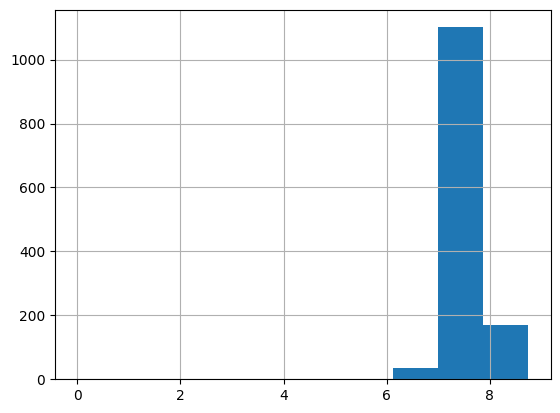

In [ ]:
df['Aroma'].hist()

The data is not normally distributed, with most of the records hanging around the 7.8 or 7.9 area. Due to this, it is better for us to just take the middle 50% of data, and consider everything else as an outlier. We start this process by finding the interquartile range, which is done by subtracting the third and first quartile.

In [ ]:
IQR = df['Aroma'].quantile(0.75) - df['Aroma'].quantile(0.25)
print(IQR)

0.33000000000000007


We then get the lower and upper limit with the formulas:

Lower Limit = Q1 - 1.5*IQR

Upper Limit = Q3 + 1.5*IQR

In [ ]:
LowerLim = df['Aroma'].quantile(0.25) - 1.5*IQR
UpperLim = df['Aroma'].quantile(0.75) + 1.5*IQR

print("Lower Limit: ", LowerLim)
print("Upper Limit: ", UpperLim)

Lower Limit:  6.925
Upper Limit:  8.245000000000001


With these limits, we can now find any outliers in the data.

In [ ]:
outliers = df[(df['Aroma'] < LowerLim) | (df['Aroma'] > UpperLim)]
print("There are", len(outliers), "outliers")

There are 69 outliers


Lets analyze these outliers to determine what kind of response we should have to their presence in the dataset.

In [ ]:
outliers['Aroma'].describe()

,Aroma
count,69.000000
mean,7.381014
std,1.250546
min,0.000000
25%,6.830000
50%,6.920000
75%,8.330000
max,8.750000


With 69 records being outliers, we can't just drop them. However, there is 1 record with a 0 value which can be considered an extreme value and thus should be dropped. That record will be dropped, but the other values will be left as is since they are not extremely high nor extremely low

In [ ]:
df = df[(df['Aroma'] > 0)]

<h2> Flavor </h2>

Let's start by looking at the distribution of data

<Axes: >

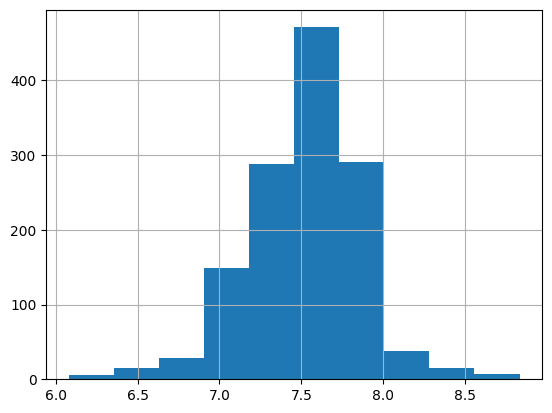

In [ ]:
df['Flavor'].hist()

Given that the distribution of the flavor scores looks relatively normal, what we can do is get the z-score of each record and then considering any record that goes over a threshold of three standard deviations as an outlier.

In [ ]:
mean = df['Flavor'].mean()
std = df['Flavor'].std()

threshold = 3
zscores = np.abs((df['Flavor'] - mean)/std)
outliers = df[zscores > threshold]
print("There are", len(outliers), "outliers")


There are 23 outliers


Lets see what these outliers look like.

In [ ]:
outliers['Flavor'].describe()

,Flavor
count,23.000000
mean,7.086957
std,1.076203
min,6.080000
25%,6.375000
50%,6.500000
75%,8.580000
max,8.830000


With only 23 records, we can safely drop these outliers since it won't constitute as a major loss in data.



<Axes: >

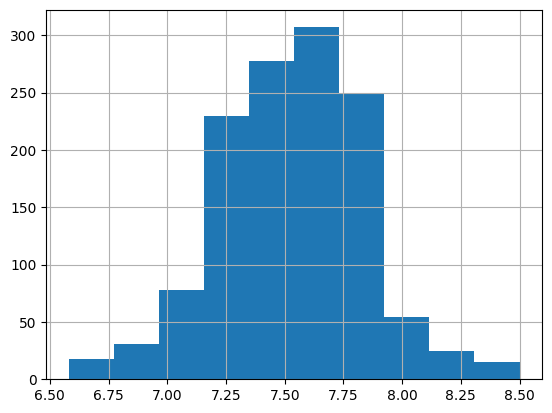

In [ ]:
df= df[zscores <= threshold]
df['Flavor'].hist()

<h2> Aftertaste </h2>
Let's follow the same process for aftertaste

<Axes: >

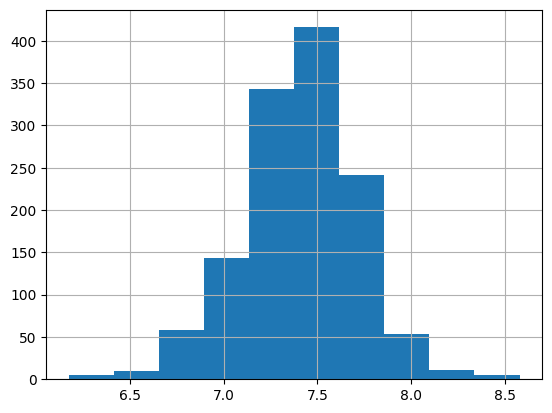

In [ ]:
df['Aftertaste'].hist()

With a similar normal distribution, we can follow the same process as we did in the last section.

In [ ]:
mean = df['Aftertaste'].mean()
std = df['Aftertaste'].std()

threshold = 3
zscores = np.abs((df['Aftertaste'] - mean)/std)
outliers = df[zscores > threshold]
print("There are", len(outliers), "outliers")


There are 12 outliers


With only 12 outliers, we can safely drop the outlier records.

<Axes: >

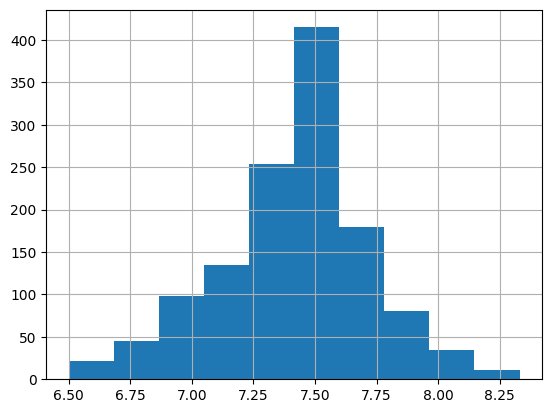

In [ ]:
df= df[zscores <= threshold]
df['Aftertaste'].hist()

<h2> Acidity</h2>

<Axes: >

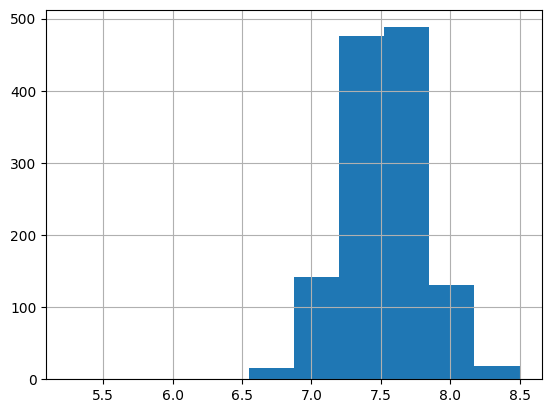

In [ ]:
df['Acidity'].hist()

Since this feature is also generally normal, we can continue with the same process as before.

In [ ]:
mean = df['Acidity'].mean()
std = df['Acidity'].std()

threshold = 3
zscores = np.abs((df['Acidity'] - mean)/std)
outliers = df[zscores > threshold]
print("There are", len(outliers), "outliers")

There are 6 outliers


In [ ]:
outliers['Acidity'].describe()

,Acidity
count,6.00000
mean,7.55500
std,1.48733
min,5.25000
25%,6.68500
50%,8.50000
75%,8.50000
max,8.50000


With only 6 nonextreme outliers, we can assume that these values are just random low ratings that aren't really contaminating our data. Therefore, we won't drop the outlier values.

<h2> Body </h2>
Lets start again by taking a look at the distribution.

<Axes: >

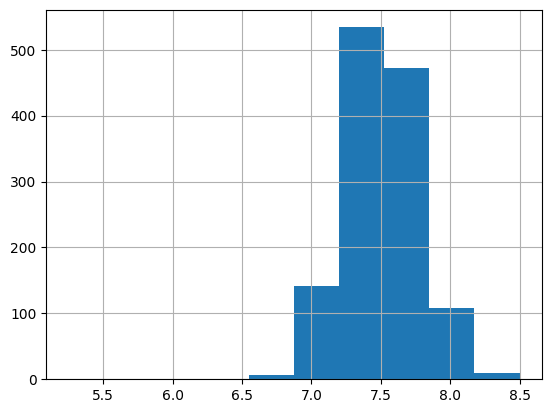

In [ ]:
df['Body'].hist()

With a similarly normal distribution, let's follow the same process as before.

In [ ]:
mean = df['Body'].mean()
std = df['Body'].std()

threshold = 3
zscores = np.abs((df['Body'] - mean)/std)
outliers = df[zscores > threshold]
print("There are", len(outliers), "outliers")

There are 5 outliers


In [ ]:
outliers['Body'].describe()

,Body
count,5.000000
mean,7.452000
std,1.451954
min,5.250000
25%,6.670000
50%,8.420000
75%,8.420000
max,8.500000


Similarly to before we can just assume that these values are just random low or high ratings that don't contaminate our data. Therefore, we won't drop the outlier values.

<h2> Balance </h2>

<Axes: >

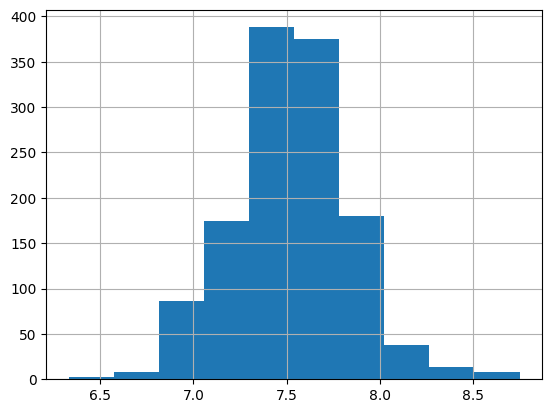

In [ ]:
df['Balance'].hist()

The balance column also follows a normal distribution. Therefore, we will follow the same process.

In [ ]:
mean = df['Balance'].mean()
std = df['Balance'].std()

threshold = 3
zscores = np.abs((df['Balance'] - mean)/std)
outliers = df[zscores > threshold]
print("There are", len(outliers), "outliers")

There are 10 outliers


In [ ]:
outliers['Balance'].describe()

,Balance
count,10.000000
mean,8.156000
std,0.940404
min,6.330000
25%,8.580000
50%,8.580000
75%,8.580000
max,8.750000


10 outlier records is a larger amount compared to the previous few columns which both had less than ten outliers. This may represent a trend of extreme values that may contaminate our data. To be safe, lets drop these 11 records.

<Axes: >

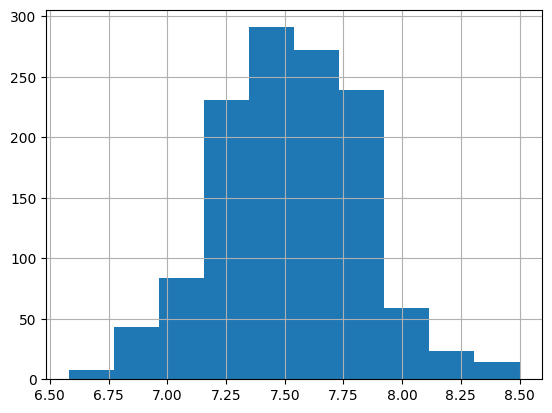

In [ ]:
df= df[zscores <= threshold]
df['Balance'].hist()

<h2> Uniformity </h2>

Lets look at the distribution of this feature.

<Axes: >

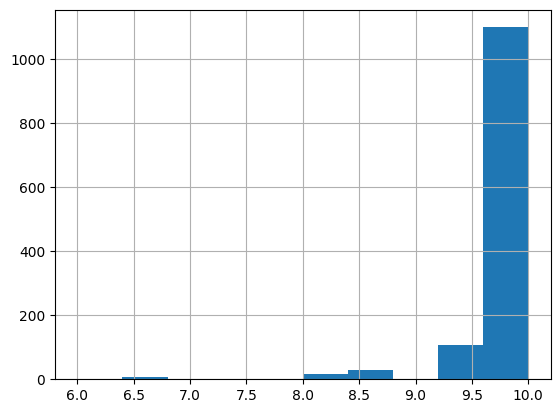

In [ ]:
df['Uniformity'].hist()

These values are not normally distributed, so lets follow the process we did for the Aroma feature.

In [ ]:
IQR = df['Uniformity'].quantile(0.75) - df['Uniformity'].quantile(0.25)
print(IQR)

0.0


In [ ]:
LowerLim = df['Uniformity'].quantile(0.25) - 1.5*IQR
UpperLim = df['Uniformity'].quantile(0.75) + 1.5*IQR

print("Lower Limit: ", LowerLim)
print("Upper Limit: ", UpperLim)

Lower Limit:  10.0
Upper Limit:  10.0


In [ ]:
outliers = df[(df['Uniformity'] < LowerLim) | (df['Uniformity'] > UpperLim)]
print("There are", len(outliers), "outliers")

There are 165 outliers


In [ ]:
outliers['Uniformity'].describe()

,Uniformity
count,165.000000
mean,8.892485
std,0.751520
min,6.000000
25%,8.670000
50%,9.330000
75%,9.330000
max,9.500000


While there are a large amount of outliers, which would normally indicate a trend of contaminated data. However, removing the data would only leave records with a uniformity of 10. This is bad because it may harm the way the future model learns since there will be no trend of uniformity for it to learn from. Due to this, we won't drop any values present.

<h2> Clean Cup </h2>
Let's look at the distribution of this feature

<Axes: >

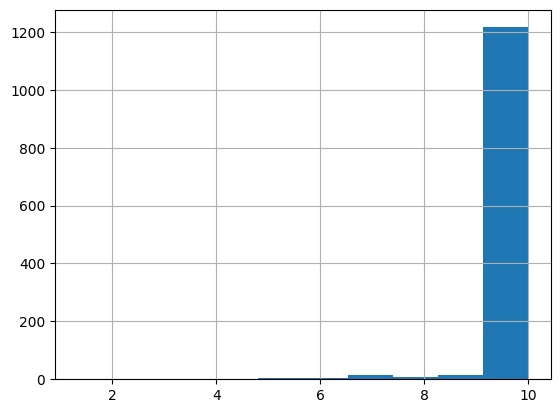

In [ ]:
df['Clean.Cup'].hist()

Visually, the data looks similar to that of the uniformity feature, and it is likely that going through the same prcoess as uniformity will have the same results.

In [ ]:
IQR = df['Clean.Cup'].quantile(0.75) - df['Clean.Cup'].quantile(0.25)

LowerLim = df['Clean.Cup'].quantile(0.25) - 1.5*IQR
UpperLim = df['Clean.Cup'].quantile(0.75) + 1.5*IQR

print("Lower Limit: ", LowerLim)
print("Upper Limit: ", UpperLim)

Lower Limit:  10.0
Upper Limit:  10.0


In [ ]:
outliers = df[(df['Clean.Cup'] < LowerLim) | (df['Clean.Cup'] > UpperLim)]
print("There are", len(outliers), "outliers")

There are 106 outliers


In [ ]:
outliers['Clean.Cup'].describe()

,Clean.Cup
count,106.000000
mean,8.376226
std,1.543875
min,1.330000
25%,8.000000
50%,9.330000
75%,9.330000
max,9.330000


Similar to before, every record with a clean cup rating below a 10.0 will be branded as an outlier. Removing these records would actively harm our data and our future model, so we will not be dropping them. Additionally, these low ratings could represent a trend that we would be missing out on should we drop them. However, there is an extremely low value in the minimum which gives a value of 1.33. This may actually represent a misinput of data so dropping that record in particular would be prudent.

In [ ]:
df = df[df['Clean.Cup'] != 1.33]

<h2> Sweetness </h2>
Let's look at the distribution of the sweetness feature.

<Axes: >

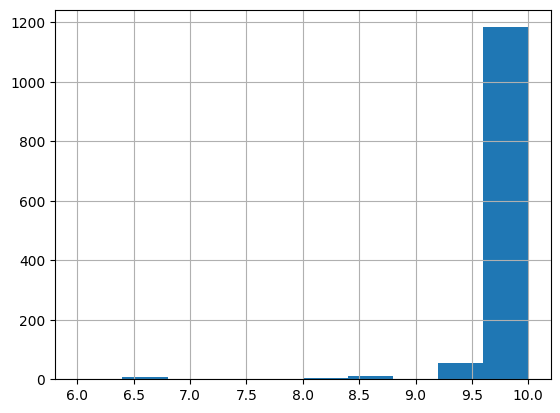

In [ ]:
df['Sweetness'].hist()

The sweetness feature also looks similar to the previous two features in terms of distribution. Lets follow the same process as we did before.

In [ ]:
IQR = df['Sweetness'].quantile(0.75) - df['Sweetness'].quantile(0.25)

LowerLim = df['Sweetness'].quantile(0.25) - 1.5*IQR
UpperLim = df['Sweetness'].quantile(0.75) + 1.5*IQR

print("Lower Limit: ", LowerLim)
print("Upper Limit: ", UpperLim)

Lower Limit:  10.0
Upper Limit:  10.0


In [ ]:
outliers = df[(df['Sweetness'] < LowerLim) | (df['Sweetness'] > UpperLim)]
print("There are", len(outliers), "outliers")

There are 80 outliers


In [ ]:
outliers['Sweetness'].describe()

,Sweetness
count,80.00000
mean,8.88175
std,0.85817
min,6.00000
25%,8.67000
50%,9.33000
75%,9.33000
max,9.33000


This feature has no extremely low values, so we won't drop anything as, similarly to before, dropping all values below 10 will likely lead to our model not learning anything.

<h2> Moisture </h2>
Let's look at the distribution of the moisture feature.

<Axes: >

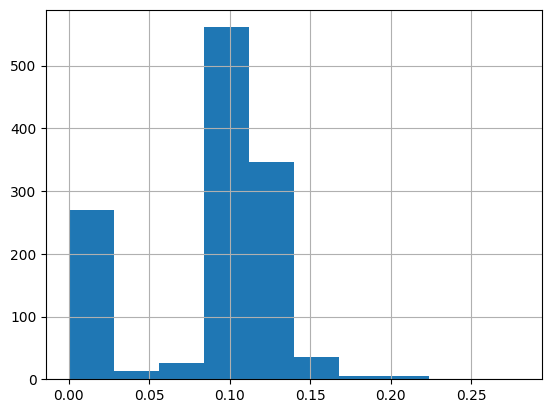

In [ ]:
df['Moisture'].hist()

This feature, does not have a normal distribution, with a large amount of records clustering around 0.

In [ ]:
IQR = df['Moisture'].quantile(0.75) - df['Moisture'].quantile(0.25)

LowerLim = df['Moisture'].quantile(0.25) - 1.5*IQR
UpperLim = df['Moisture'].quantile(0.75) + 1.5*IQR

print("Lower Limit: ", LowerLim)
print("Upper Limit: ", UpperLim)

Lower Limit:  0.045
Upper Limit:  0.16499999999999998


In [ ]:
outliers = df[(df['Moisture'] < LowerLim) | (df['Moisture'] > UpperLim)]
print("There are", len(outliers), "outliers")

There are 287 outliers


In [ ]:
outliers['Moisture'].describe()

,Moisture
count,287.000000
mean,0.009373
std,0.038761
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.280000


There is a large amount of data here that is just set to 0. This may represent an issue with the data collection so we need to deal with it. However, just dropping the data is unwise since it would represent a significant loss in data. Additionally, we can't clamp the data to the lower bounds since it would heavily inflate the left side of the distribution. What we can do is set a fixed random seed for reproducibility, and get a random value from the entry's Processing.Method group. This would solve the issue of the extreme near 0 values while preserving the distribution of the feature as best as possible.

In [ ]:
rng = np.random.default_rng(42)

df["Moisture"] = df["Moisture"].replace(0, np.nan)
mask = df["Moisture"].isna()

for pm in df.loc[mask, "Processing.Method"].dropna().unique():
    idx = mask & (df["Processing.Method"] == pm)
    pool = df.loc[(~mask) & (df["Processing.Method"] == pm), "Moisture"]
    if len(pool) > 0:
        df.loc[idx, "Moisture"] = rng.choice(pool.to_numpy(), size=idx.sum(), replace=True)

# fallback if any still missing
remaining = df["Moisture"].isna()
if remaining.any():
    global_pool = df.loc[~df["Moisture"].isna(), "Moisture"].to_numpy()
    df.loc[remaining, "Moisture"] = rng.choice(global_pool, size=remaining.sum(), replace=True)

<Axes: >

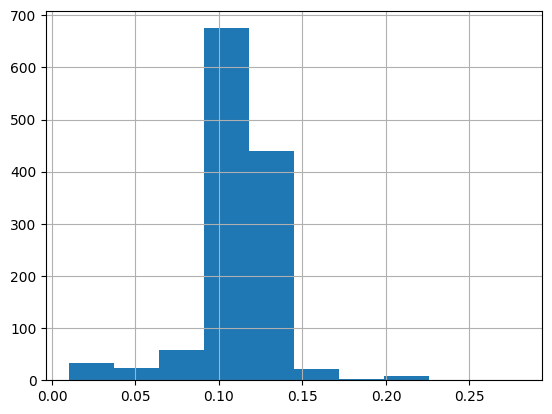

In [ ]:
df['Moisture'].hist()

We will keep the other non zero values since they are low enough in quantity such that we can just assume they represent real data entries that are just really dry or really moist compared to average coffee.

<h2> Quakers </h2>
Finally, lets look at the Quakers feature.

<Axes: >

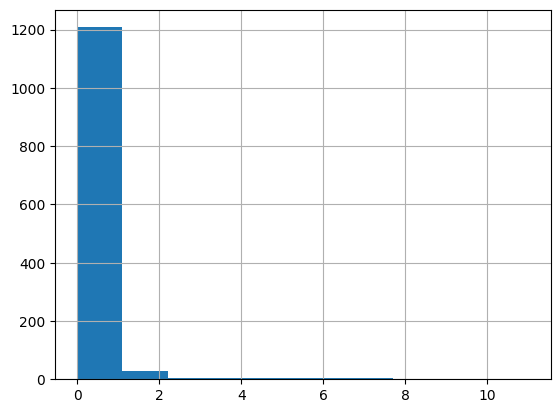

In [ ]:
df['Quakers'].hist()

There are a large amount of 0's in this dataset, however it is not alarming given context. In the real world, quakers are underdeveloped beans that find their way into the final coffee. As such, most mid-high quality coffees try to have none of them as much as possible. In this sense, the high 0 count makes perfect sense. However, we should still look if there are any extreme values present in the data.

In [ ]:
IQR = df['Quakers'].quantile(0.75) - df['Quakers'].quantile(0.25)

LowerLim = df['Quakers'].quantile(0.25) - 1.5*IQR
UpperLim = df['Quakers'].quantile(0.75) + 1.5*IQR

print("Lower Limit: ", LowerLim)
print("Upper Limit: ", UpperLim)

Lower Limit:  0.0
Upper Limit:  0.0


In [ ]:
outliers = df[(df['Quakers'] < LowerLim) | (df['Quakers'] > UpperLim)]
print("There are", len(outliers), "outliers")

There are 93 outliers


In [ ]:
outliers['Quakers'].describe()

,Quakers
count,93.000000
mean,2.483871
std,2.062148
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,11.000000


Most of these values seem non-extreme. The only record that suggests a misinput along with any records with a quaker value above 7. Lets drop these records.

In [ ]:
df = df[df['Quakers'] <= 7]

## **Exploratory Data Analysis (EDA)**





To further understand and explore what our coffee quality data reveals about the relationships between sensory characteristics and origin, we conduct a comprehensive Exploratory Data Analysis (EDA). This critical step allows us to uncover patterns, identify potential issues, and generate hypotheses before building predictive models.

First, we conduct a descriptive statistics that allows us to summarize the central tendency, spread, and shape of each sensory feature's distribution

We select the 11 sensory attributes that will serve as our primary features for predicting coffee origin.

In [ ]:
sensory_features = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
                    'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness',
                    'Moisture', 'Quakers']

We compute fundamental statistics to understand the central tendency and spread of our sensory data. The mean shows the average score for each attribute, the median reveals the middle value, standard deviation indicates consistency across samples, while min and max values help identify data quality issues and exceptional cases.

In [ ]:
stats = df[sensory_features].agg(['mean', 'median', 'std', 'min', 'max']).round(4)
print("Descriptive Statistics for Sensory Features:")
print(stats)

Descriptive Statistics for Sensory Features:
         Aroma  Flavor  Aftertaste  Acidity    Body  Balance  Uniformity  \
mean    7.5765  7.5348      7.4151   7.5417  7.5269   7.5256      9.8566   
median  7.5800  7.5800      7.4200   7.5800  7.5000   7.5000     10.0000   
std     0.2910  0.2977      0.3023   0.2982  0.2749   0.3101      0.4589   
min     5.0800  6.5800      6.5000   5.2500  5.2500   6.5800      6.0000   
max     8.5000  8.5000      8.3300   8.5000  8.5000   8.5000     10.0000   

        Clean.Cup  Sweetness  Moisture  Quakers  
mean       9.8703     9.9290    0.1099   0.1611  
median    10.0000    10.0000    0.1100   0.0000  
std        0.5867     0.3473    0.0239   0.7275  
min        2.6700     6.0000    0.0100   0.0000  
max       10.0000    10.0000    0.2800   7.0000  




*   Mean & Median: Core attributes (Aroma, Flavor, Acidity, Body, Balance) cluster around 7.5, indicating consistently high-quality specialty coffee. Uniformity, Clean Cup, and Sweetness have means near 10, showing most samples are defect-free.

*   Standard Deviation: Low values (0.27-0.31) for core attributes indicate minimal variation, which also indicates that most coffees taste remarkably similar. High std for Quakers (0.73) confirms it's a defect-based feature with rare outliers.

*  Min/Max: The ranges show no extreme data entry errors, but the narrow spreads (most scores between 7.0-8.5) confirm that origin prediction will be challenging since sensory profiles are so homogeneous across samples.



We then calculate quartiles to understand the distribution of scores more robustly.

In [ ]:
print("Quartile Statistics:")
for feature in sensory_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1
    print(f"{feature}:")
    print(f"  Q1: {q1:.3f}, Q3: {q3:.3f}, IQR: {iqr:.3f}")
    print(f"  Skewness: {df[feature].skew():.3f}")
    print(f"  Kurtosis: {df[feature].kurtosis():.3f}")

Quartile Statistics:
Aroma:
  Q1: 7.420, Q3: 7.750, IQR: 0.330
  Skewness: -0.397
  Kurtosis: 4.399
Flavor:
  Q1: 7.330, Q3: 7.750, IQR: 0.420
  Skewness: -0.091
  Kurtosis: 0.394
Aftertaste:
  Q1: 7.250, Q3: 7.580, IQR: 0.330
  Skewness: -0.163
  Kurtosis: -0.022
Acidity:
  Q1: 7.330, Q3: 7.750, IQR: 0.420
  Skewness: -0.252
  Kurtosis: 2.761
Body:
  Q1: 7.330, Q3: 7.670, IQR: 0.340
  Skewness: -0.361
  Kurtosis: 3.589
Balance:
  Q1: 7.330, Q3: 7.750, IQR: 0.420
  Skewness: -0.002
  Kurtosis: 0.224
Uniformity:
  Q1: 10.000, Q3: 10.000, IQR: 0.000
  Skewness: -4.471
  Kurtosis: 24.243
Clean.Cup:
  Q1: 10.000, Q3: 10.000, IQR: 0.000
  Skewness: -6.713
  Kurtosis: 55.932
Sweetness:
  Q1: 10.000, Q3: 10.000, IQR: 0.000
  Skewness: -7.072
  Kurtosis: 59.085
Moisture:
  Q1: 0.100, Q3: 0.120, IQR: 0.020
  Skewness: -1.056
  Kurtosis: 9.679
Quakers:
  Q1: 0.000, Q3: 0.000, IQR: 0.000
  Skewness: 6.041
  Kurtosis: 41.804


The quartile statistics reveal highly homogeneous sensory profiles, with core attributes (Aroma, Flavor, Aftertaste, Acidity, Body, Balance) tightly clustered between 7.3-7.8 (IQR: 0.33-0.42). Uniformity, Clean Cup, Sweetness, and Quakers show zero IQR with most samples at perfect scores, offering minimal predictive value. This consistency across high-quality specialty coffees suggests origin prediction will be challenging, requiring detection of subtle multi-feature patterns rather than relying on any single discriminating attribute.

Negative skew means most coffees scored high with just a few low-scoring ones, leaning towards right (Aroma, Flavor, Aftertaste, Acidity, Body, Balance, Moisture, Uniformity, Clean Cup and Sweetness). Positive skew means most scored low with a few high-scoring ones, leaning towards left (Quakers).

High kurtosis (Uniformity, Clean Cup, Sweetness, Quakers, Moisture, Aroma, Body, Acidity) indicates most values cluster tightly at one point, but when outliers occur, they're extreme. Low kurtosis (Aftertaste, Balance, Flavor) means values are more evenly spread with no extreme outliers.

Next, we now conduct a target variable distribution analysis to understand how coffee samples are distributed across continents and countries to assess class balance.

Let's first focus on the distribution between each continent.

In [ ]:
continent_dist = df['Continent.of.Origin'].value_counts()
continent_percent = df['Continent.of.Origin'].value_counts(normalize=True) * 100

continent_summary = pd.DataFrame({
    'Count': continent_dist,
    'Percentage': continent_percent.round(2)
})
print(continent_summary)

                     Count  Percentage
Continent.of.Origin                   
North America          631       50.08
South America          320       25.40
Asia                   165       13.10
Africa                 143       11.35
Oceania                  1        0.08


This data indicates that there's an imbalance in our model as it is biased toward North America. Most critically, Oceania has only 1 sample, making reliable prediction for this continent impossible.


We drop Oceania, as there wouldn't be enough data to train the model on.

In [ ]:
df = df[df["Continent.of.Origin"] != "Oceania"].copy()
print("Remaining continent counts after dropping Oceania:")
print(df["Continent.of.Origin"].value_counts())

Remaining continent counts after dropping Oceania:
Continent.of.Origin
North America    631
South America    320
Asia             165
Africa           143
Name: count, dtype: int64


Let's now focus on the distribution between each country.

In [ ]:
country_dist = df['Country.of.Origin'].value_counts()
country_percent = df['Country.of.Origin'].value_counts(normalize=True) * 100

country_summary = pd.DataFrame({
    'Count': country_dist,
    'Percentage': country_percent.round(2)
})
print(country_summary.head(20))

                   Count  Percentage
Country.of.Origin                   
Mexico               231       18.35
Colombia             180       14.30
Guatemala            165       13.11
Brazil               129       10.25
United States         83        6.59
Taiwan                75        5.96
Honduras              49        3.89
Costa Rica            49        3.89
Tanzania              40        3.18
Ethiopia              35        2.78
Thailand              32        2.54
Uganda                26        2.07
Nicaragua             25        1.99
Kenya                 25        1.99
El Salvador           21        1.67
Indonesia             19        1.51
China                 16        1.27
Malawi                11        0.87
Peru                  10        0.79
Myanmar                8        0.64


The top 5 countries (Mexico, Colombia, Guatemala, Brazil, US) account for over 62% of all samples, while the remaining countries have minimal representation. This indicates that country-level prediction is infeasible as the model would simply learn to predict majority countries and fail on the many underrepresented origins. **This strongly supports that it's better to predict continent rather than country as the target variable**.

To ensure that our independent variables are statistically significant, and to provide insight on to future needs for regularization during training, we view the multi-collinearity of our features.

We select our numeric predictors of the target

In [ ]:
num_features = [
    "Aroma", "Aftertaste", "Acidity", "Body", "Balance",
    "Uniformity", "Clean.Cup", "Sweetness", "Moisture", "Quakers", "Flavor"
]

X_num = df[num_features].copy()

We plot out the feature-to-feature correlation matrix

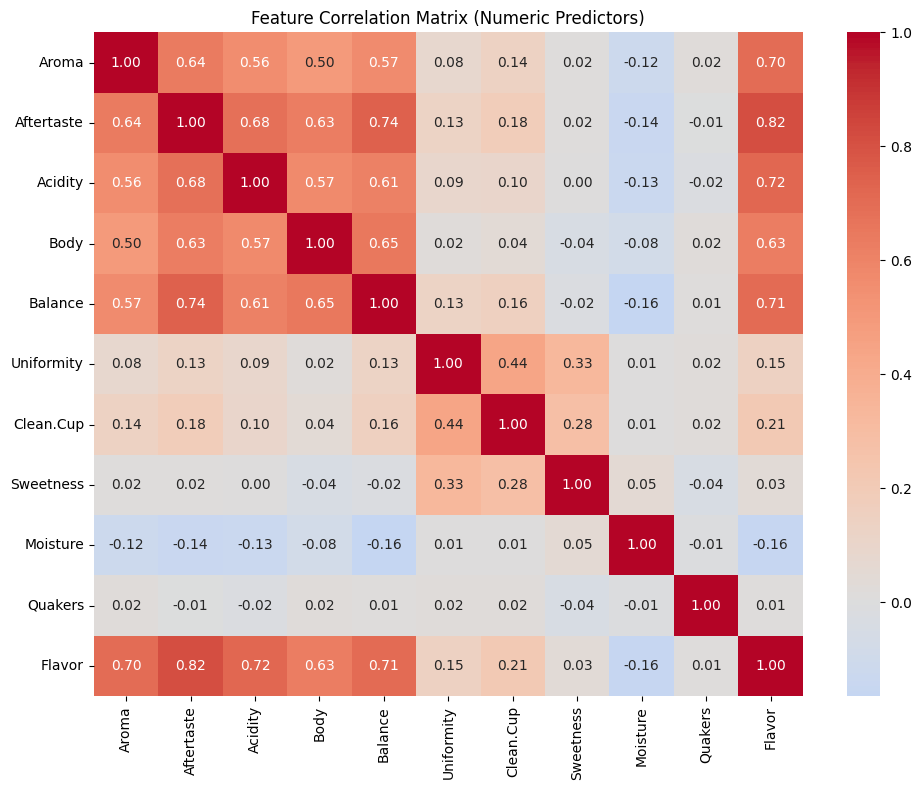

In [ ]:
corr = X_num.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (Numeric Predictors)")
plt.tight_layout()
plt.show()

We now pinpoint which among these have the strongest correlation

In [ ]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
corr_pairs["AbsCorr"] = corr_pairs["Correlation"].abs()
corr_pairs = corr_pairs.sort_values("AbsCorr", ascending=False)

print("Top correlated feature pairs:")
display(corr_pairs.head(10))

Top correlated feature pairs:


,Feature_1,Feature_2,Correlation,AbsCorr
18,Aftertaste,Flavor,0.815349,0.815349
12,Aftertaste,Balance,0.741597,0.741597
26,Acidity,Flavor,0.718303,0.718303
39,Balance,Flavor,0.705729,0.705729
9,Aroma,Flavor,0.695980,0.695980
10,Aftertaste,Acidity,0.678272,0.678272
27,Body,Balance,0.650145,0.650145
0,Aroma,Aftertaste,0.635024,0.635024
11,Aftertaste,Body,0.629290,0.629290
33,Body,Flavor,0.625483,0.625483


Seeing that aftertaste and flavor has a greater than 0.8 correlation, we use Variance Inflation Factor (VIF) to measure the severity of our features' multi-collinearity. Generally, a VIF of greater than 5 indicates a need for corrective action like dropping a feature.

In [ ]:
def compute_vif(df_num):
    vif_rows = []
    cols = df_num.columns.tolist()

    for col in cols:
        y = df_num[col]
        X = df_num.drop(columns=[col])

        model = LinearRegression()
        model.fit(X, y)
        r2 = model.score(X, y)

        vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
        vif_rows.append({"Feature": col, "VIF": vif})

    return pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)

X_vif = X_num.dropna().copy()
vif_df = compute_vif(X_vif)
display(vif_df)

,Feature,VIF
10,Flavor,4.231465
1,Aftertaste,3.753898
4,Balance,2.705983
2,Acidity,2.289463
3,Body,2.043745
0,Aroma,2.025306
5,Uniformity,1.336440
6,Clean.Cup,1.333699
7,Sweetness,1.165427
8,Moisture,1.040109


Seeing that all features have VIF values below 5, there is no severe global multi-collinearity.

However, there is still a strong (>0.8) correlation between flavor and aftertaste, signaling a potential need for feature selection during training.

## **Data Visualization**

In order to visualize our quality indicators, we used boxplots to get a general look on the distribution of the features.

Using columns: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Moisture', 'Quakers']


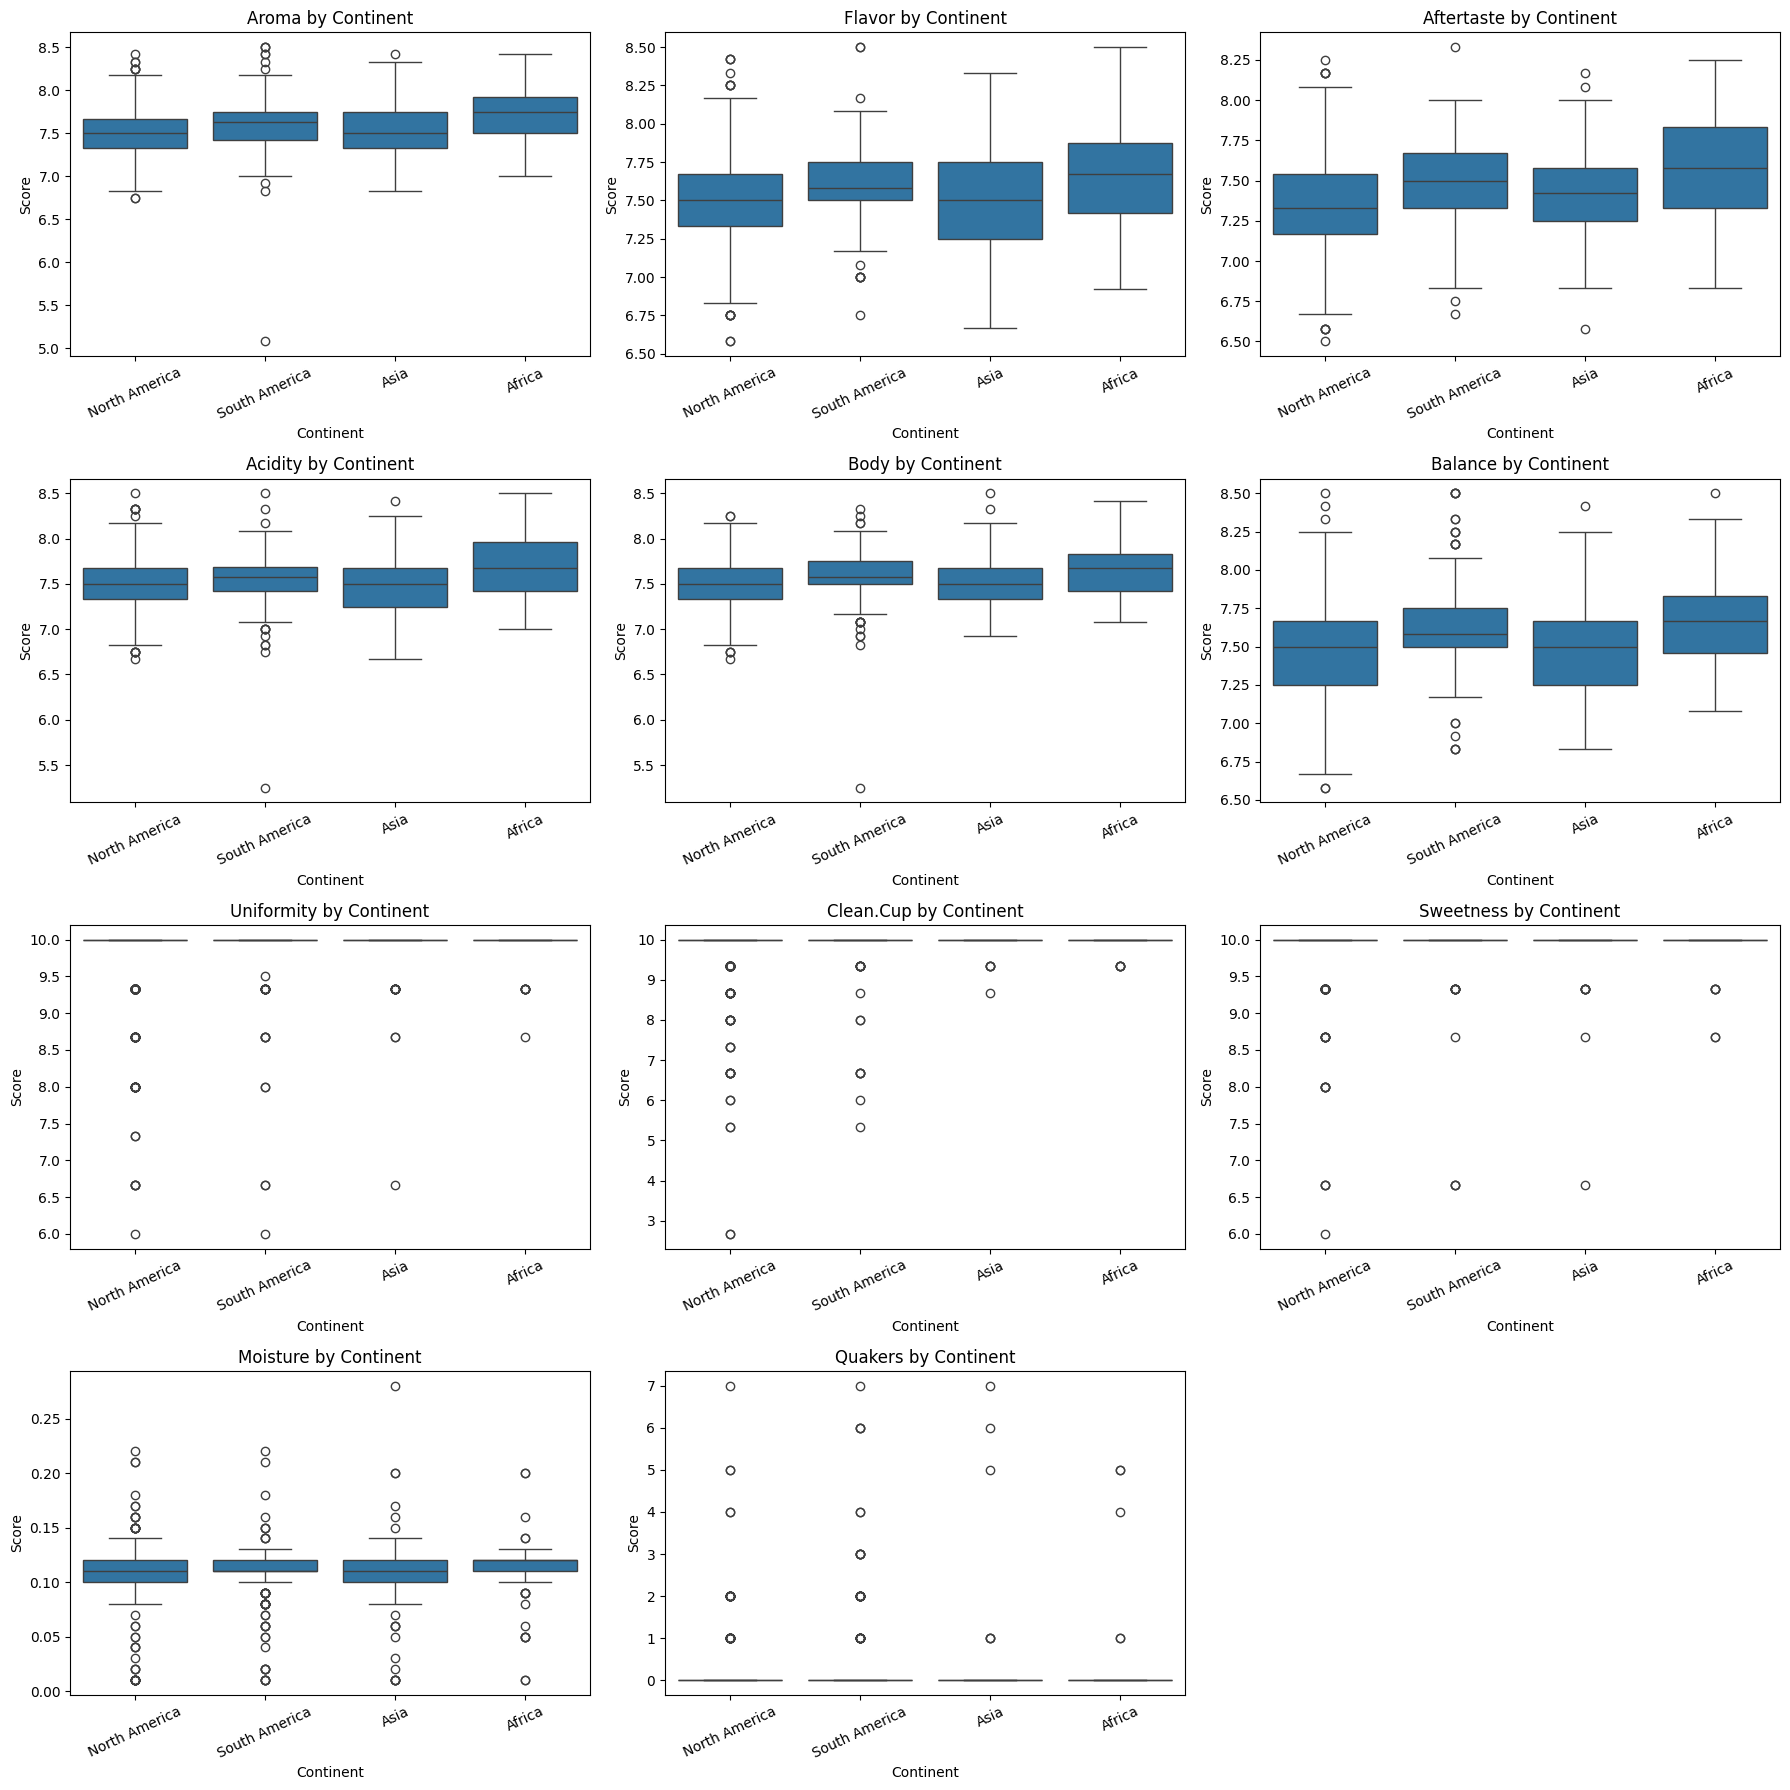

In [ ]:
quality_score_cols = [
    "Aroma", "Flavor", "Aftertaste", "Acidity", "Body",
    "Balance", "Uniformity", "Clean.Cup", "Sweetness",
    "Moisture", "Quakers"
]

available_scores = [c for c in quality_score_cols if c in df.columns]
print("Using columns:", available_scores)

plot_df = df[["Continent.of.Origin"] + available_scores].dropna(subset=["Continent.of.Origin"]).copy()
continent_order = plot_df["Continent.of.Origin"].value_counts().index.tolist()

n_features = len(available_scores)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), squeeze=False)
axes = axes.flatten()

for i, feature in enumerate(available_scores):
    sns.boxplot(
        data=plot_df,
        x="Continent.of.Origin",
        y=feature,
        order=continent_order,
        showfliers=True,
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} by Continent")
    axes[i].set_xlabel("Continent")
    axes[i].set_ylabel("Score")
    axes[i].tick_params(axis="x", rotation=25)

for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Some features, namely Uniformity, Clean Cup, Sweetness, and Quakers are shown to have heavily skewed distributions, meaning these will probably be meaningless features, as the model would not get any inferrences on almost-equal values across all continents on these features.


## **Data Splitting**

We now partition the data into the training, validation and test set. This will be done with the train_test_split() function. We stratify to ensure that the distribution of the continents are the same across both splits, as we have a skewed distribution of continents.

In [ ]:
y = df['Continent.of.Origin']
x = df.drop(columns = ['Country.of.Origin', 'Continent.of.Origin'])

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.111209179, random_state = 42, stratify = y_train)


print("Training Set Shape: ", X_train.shape)
print("Training Labels Shape: ", y_train.shape)
print("Validation Set Shape: ", X_val.shape)
print("Validation Labels Shape: ", y_val.shape)
print("Test Set Shape: ", X_test.shape)
print("Test Labels Shape: " , y_test.shape)

Training Set Shape:  (1007, 22)
Training Labels Shape:  (1007,)
Validation Set Shape:  (126, 22)
Validation Labels Shape:  (126,)
Test Set Shape:  (126, 22)
Test Labels Shape:  (126,)


To get a statistically-significant and efficient subset of features to use in our pipeline, we do feature selection.

We remove metadata from the predictive feature, as this project focuses on the characteristics of the coffee itself, not when it's harvested, when it would expire, or how it is processed.

We remove Variety, as it has 201 null entries, and is considered as a general classification of the coffee, instead of an attribute.

We remove heavily skewed and non-normally distributed features Uniformity, Clean Cup, Sweetness, Moisture, and Quakers.

We are left with Aroma, Aftertaste, Acidity, Body, Balance, Color, and Flavor.

With Flavor and Aftertaste having the highest VIF (4.2), we compare the two subset features' Macro-F1 on a Logistic Regression to determine if there is a significant difference in performance with one over the other.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

feature_sets = {
    "Aftertaste + Flavor": (["Aroma", "Aftertaste", "Acidity", "Body", "Balance", "Flavor"], ["Color"]),
    "Flavor only":         (["Aroma", "Acidity", "Body", "Balance", "Flavor"],                ["Color"]),
    "Aftertaste only":     (["Aroma", "Aftertaste", "Acidity", "Body", "Balance"],            ["Color"]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for label, (num_feats, cat_feats) in feature_sets.items():
    num_cols = [c for c in num_feats if c in X_train.columns]
    cat_cols = [c for c in cat_feats if c in X_train.columns]

    pre = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

    pipe = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    print(f"{label:25s}  Macro-F1 = {scores.mean():.4f} ± {scores.std():.4f}")


Aftertaste + Flavor        Macro-F1 = 0.3817 ± 0.0306
Flavor only                Macro-F1 = 0.3699 ± 0.0217
Aftertaste only            Macro-F1 = 0.3833 ± 0.0230


As we can see, the subset Aroma, Aftertaste, Acidity, Body, Balance, and Color perform the best, thus this will be our final set of features.

With our dataset properly split, we can now standardize  the sensory values of each individual dataset. We choose to standardize instead of normalize since standardization is less sensitive to any outliers.

In [ ]:
final_num_cols = ["Aroma", "Aftertaste", "Acidity", "Body", "Balance"]
scaler = StandardScaler()
X_train[final_num_cols] = scaler.fit_transform(X_train[final_num_cols])
X_train.head()

,REC_ID,Species,Harvest.Year,Variety,Color,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,...,Uniformity,Clean.Cup,Sweetness,Moisture,Quakers,Category.One.Defects,Category.Two.Defects,Expiration-Year,Expiration-Month,Expiration-Day
1200,1200,Arabica,2012,Typica,Green,Washed / Wet,0.318467,7.17,-1.120566,-0.986434,...,8.67,9.33,9.33,0.11,0,0,4,2014,1,8
913,913,Arabica,2017,Bourbon,Green,Other,-0.261948,7.42,-0.561833,-0.986434,...,10.00,10.00,10.00,0.12,0,0,0,2018,6,1
1220,1220,Arabica,2013,Missing,Green,Other,1.172020,6.83,-1.120566,-0.418583,...,8.67,9.33,10.00,0.02,0,0,0,2012,6,20
339,339,Arabica,2015,Caturra,Green,Washed / Wet,0.318467,7.75,0.522765,0.416493,...,10.00,10.00,10.00,0.12,0,0,3,2016,11,18
1081,1081,Arabica,2013,Bourbon,Green,Washed / Wet,-0.842364,7.17,-1.120566,-1.554285,...,10.00,10.00,10.00,0.11,0,0,1,2015,4,26


In [ ]:
X_val[final_num_cols] = scaler.transform(X_val[final_num_cols])
X_val.head()

,REC_ID,Species,Harvest.Year,Variety,Color,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,...,Uniformity,Clean.Cup,Sweetness,Moisture,Quakers,Category.One.Defects,Category.Two.Defects,Expiration-Year,Expiration-Month,Expiration-Day
19,19,Arabica,2014,Ethiopian Yirgacheffe,Green,Natural / Dry,2.025572,8.17,1.903163,2.086643,...,10.0,10.0,10.0,0.09,0,0,8,2016,3,24
456,456,Arabica,2014,SL14,Bluish-Green,Washed / Wet,1.445156,7.67,0.259832,-0.418583,...,10.0,10.0,10.0,0.10,0,0,0,2015,10,28
234,234,Arabica,2016,Bourbon,Green,Washed / Wet,1.445156,7.75,0.259832,0.115866,...,10.0,10.0,10.0,0.10,0,0,4,2017,4,27
966,966,Arabica,2014,Pacamara,Bluish-Green,Washed / Wet,-0.842364,7.42,-0.824766,-0.986434,...,10.0,10.0,10.0,0.09,0,0,2,2016,3,20
887,887,Arabica,2013,Typica,Green,Washed / Wet,-0.261948,7.42,-1.120566,0.115866,...,10.0,10.0,10.0,0.12,0,0,6,2014,3,29


In [ ]:
X_test[final_num_cols] = scaler.transform(X_test[final_num_cols])
X_test.head()

,REC_ID,Species,Harvest.Year,Variety,Color,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,...,Uniformity,Clean.Cup,Sweetness,Moisture,Quakers,Category.One.Defects,Category.Two.Defects,Expiration-Year,Expiration-Month,Expiration-Day
1020,1020,Arabica,2014,Yellow Bourbon,Green,Natural / Dry,-1.115500,7.33,-0.561833,-0.986434,...,10.0,10.0,10.0,0.12,0,0,8,2015,12,16
382,382,Arabica,2016,Bourbon,Green,Washed / Wet,0.011189,7.50,1.081498,0.115866,...,10.0,10.0,10.0,0.11,0,0,0,2017,4,25
278,278,Arabica,2016,Missing,Green,Other,0.591604,7.67,0.259832,0.683717,...,10.0,10.0,10.0,0.08,0,0,0,2017,2,22
881,881,Arabica,2013,Sumatra,Bluish-Green,Semi-washed / Semi-pulped,-1.388637,7.42,-0.298900,-0.418583,...,10.0,10.0,10.0,0.11,0,0,0,2015,5,23
872,872,Arabica,2017,Bourbon,Green,Washed / Wet,-0.535085,7.33,-0.824766,0.416493,...,10.0,10.0,10.0,0.12,1,0,3,2018,6,5


After standardization, we need to convert our categorical feature Color into a numeric encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_color = LabelEncoder()
X_train['Color'] = le_color.fit_transform(X_train['Color'].astype(str))
X_val['Color'] = X_val['Color'].astype(str).map(
    lambda s: le_color.transform([s])[0] if s in le_color.classes_ else -1
)
X_test['Color'] = X_test['Color'].astype(str).map(
    lambda s: le_color.transform([s])[0] if s in le_color.classes_ else -1
)

We now trim our dataset to represent our final feature set

In [ ]:
final_features = ["Aroma", "Aftertaste", "Acidity", "Body", "Balance", "Color"]
X_train = X_train[final_features]
X_test = X_test[final_features]
X_val = X_val[final_features]

Let us confirm that our categorical features are changed to numerical values

In [ ]:
print("Training Set:")
X_train.head()

Training Set:


,Aroma,Aftertaste,Acidity,Body,Balance,Color
1200,0.318467,-1.120566,-0.986434,1.713779,-0.070897,2
913,-0.261948,-0.561833,-0.986434,-0.104128,-0.883290,2
1220,1.172020,-1.120566,-0.418583,-2.830988,-0.623324,2
339,0.318467,0.522765,0.416493,0.804825,0.189069,2
1081,-0.842364,-1.120566,-1.554285,-0.722216,-1.143256,2


Let's also confirm the same for the validation set

In [ ]:
print("Validation Set:")
X_val.head()

Validation Set:


,Aroma,Aftertaste,Acidity,Body,Balance,Color
19,2.025572,1.903163,2.086643,2.004644,2.626248,2
456,1.445156,0.259832,-0.418583,-0.722216,0.189069,1
234,1.445156,0.259832,0.115866,1.422914,0.481530,2
966,-0.842364,-0.824766,-0.986434,-0.394993,-0.623324,1
887,-0.261948,-1.120566,0.115866,-0.722216,-0.623324,2


Let us do the same on the test set.

In [ ]:
print("Test Set:")
X_test.head()

Test Set:


,Aroma,Aftertaste,Acidity,Body,Balance,Color
1020,-1.115500,-0.561833,-0.986434,-1.013081,-0.623324,2
382,0.011189,1.081498,0.115866,0.804825,0.481530,2
278,0.591604,0.259832,0.683717,0.804825,0.481530,2
881,-1.388637,-0.298900,-0.418583,-0.722216,-0.330863,1
872,-0.535085,-0.824766,0.416493,-0.722216,-0.330863,2


Since our target variable Continent.of.Origin consists of categorical strings, we must convert them into a numerical format.
1. One-Hot Encoding: Converts those integers into a binary matrix. This is used for the Neural Network to allow the final layer to calculate class probabilities.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

oh_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

y_train_oh = oh_encoder.fit_transform(y_train.values.reshape(-1, 1))
y_val_oh = oh_encoder.transform(y_val.values.reshape(-1, 1))
y_test_oh = oh_encoder.transform(y_test.values.reshape(-1, 1))

detected_continents = oh_encoder.categories_[0]

print(f"Original unique continents: {len(detected_continents)}")
print(f"One-Hot Encoded shape:      {y_train_oh.shape}")

for i, continent in enumerate(detected_continents[:4]):
    print(f"  {continent} -> Column {i}")

Original unique continents: 4
One-Hot Encoded shape:      (1007, 4)
  Africa -> Column 0
  Asia -> Column 1
  North America -> Column 2
  South America -> Column 3


## **Model Implementation**

We choose Logistic Regression and Random Forest as our classical ML models.

Logistic Regression is the standard baseline for multiclass classification.

Random Forest gives way to insights on feature importance and works well on limited data.

kNN wasn't picked, as we have a class imbalance, signaling a possible bias from the model towards larger classes.

Naive Bayes wasn't picked, as our EDA shows that there is some correlation between our features, and Naive Bayes assumes independency across features.

## **Logistic Regression Implementation** ##

Let's start by visualizing the training data. In this map, Africa is red, Asia is yellow, North America is blue and South America is purple.

Text(0.5, 1.0, 'Train data')

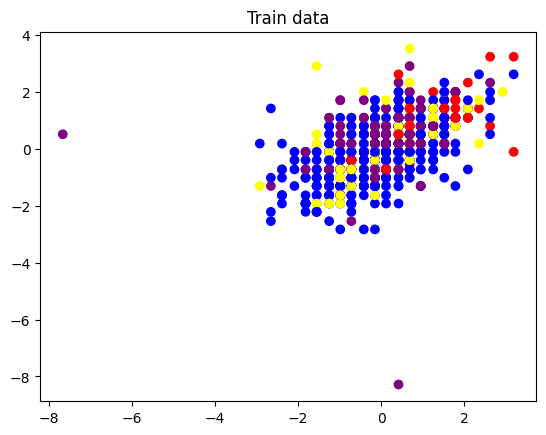

In [ ]:
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['red', 'yellow', 'blue', 'purple'])

plt.scatter(X_train.iloc[:, 2], X_train.iloc[:, 3], c=y_train_oh.argmax(axis=1), cmap=custom_cmap)
plt.title('Train data')

Lets now instantiate an SDGClassifier object which will act as our model.

In [ ]:
from sklearn.linear_model import SGDClassifier
multinomial_model = SGDClassifier(loss='log_loss', random_state=42, verbose=1)

Now, we import our data loader class and begin the process of training our model by setting our max epochs to 200

In [ ]:
from data_loader import DataLoader
max_epochs = 200

Let's instantiate a data_loader object and pass our training sets to it. Let's set our batch size to 20

In [ ]:
y_train_array = y_train_oh.argmax(axis=1)
data_loader = DataLoader(X_train.to_numpy(), y_train_array, 20)

We can now train our model until it converges, or until it reaches the maximum number of epochs

In [ ]:
from sklearn.metrics import log_loss

e = 0
is_converged = False
previous_loss = 0
labels = np.unique(y_train_array)
while e < max_epochs and is_converged is not True:

    loss = 0


    X_batch, y_batch = data_loader.get_batch()
    for X, y in zip(X_batch, y_batch):
        multinomial_model.partial_fit(X, y, classes=labels)
        y_pred = multinomial_model.predict_proba(X_train.to_numpy())
        loss += log_loss(y_train_array, y_pred)

    print('Epoch:', e + 1, '\tLoss:', (loss / len(X_batch)))
    if abs(previous_loss - loss) < 0.05:
        is_converged = True
    else:
        previous_loss = loss
        e += 1

-- Epoch 1
Norm: 21.69, NNZs: 6, Bias: -20.980650, T: 20, Avg. loss: 0.205003
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 27.82, NNZs: 6, Bias: 1.425350, T: 20, Avg. loss: 21.093133
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 43.68, NNZs: 6, Bias: 4.400055, T: 20, Avg. loss: 24.225865
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 30.91, NNZs: 6, Bias: -5.049437, T: 20, Avg. loss: 15.965325
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 21.27, NNZs: 6, Bias: -20.980658, T: 20, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 39.38, NNZs: 6, Bias: -9.077023, T: 20, Avg. loss: 2.980236
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 66.75, NNZs: 6, Bias: 14.549240, T: 20, Avg. loss: 16.155802
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 36.10, NNZs: 6, Bias: 4.461317, T: 20, Avg. loss: 8.105698
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 24.82, NNZs: 6, Bias: -11.464825, T: 20, Avg. loss: 14.747323
Total training time: 0

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Norm: 25.87, NNZs: 6, Bias: -25.467678, T: 20, Avg. loss: 2.488483
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 36.44, NNZs: 6, Bias: -9.792405, T: 20, Avg. loss: 6.993382
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 26.09, NNZs: 6, Bias: -11.265087, T: 20, Avg. loss: 13.378921
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 31.62, NNZs: 6, Bias: -28.307585, T: 20, Avg. loss: 9.466182
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 23.36, NNZs: 6, Bias: -14.424833, T: 20, Avg. loss: 4.588182
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 35.45, NNZs: 6, Bias: -15.319084, T: 20, Avg. loss: 1.455617
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 21.55, NNZs: 6, Bias: -7.339299, T: 20, Avg. loss: 10.816445
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 26.28, NNZs: 6, Bias: -29.829744, T: 20, Avg. loss: 11.912827
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 19.15, NNZs: 6, Bias: -19.930817, T: 20, Avg. loss: 5.271012
Total training time: 0.00 se

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

-- Epoch 1
Norm: 14.46, NNZs: 6, Bias: -26.815061, T: 20, Avg. loss: 3.916727
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 32.11, NNZs: 6, Bias: -15.055960, T: 20, Avg. loss: 1.970189
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 28.05, NNZs: 6, Bias: -2.239840, T: 20, Avg. loss: 4.812797
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 19.45, NNZs: 6, Bias: -9.652476, T: 20, Avg. loss: 6.299489
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 14.25, NNZs: 6, Bias: -23.228566, T: 20, Avg. loss: 1.935442
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 30.46, NNZs: 6, Bias: -7.425373, T: 20, Avg. loss: 2.537074
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 26.16, NNZs: 6, Bias: -9.044989, T: 20, Avg. loss: 7.882896
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 23.33, NNZs: 6, Bias: -2.765621, T: 20, Avg. loss: 8.346642
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 16.77, NNZs: 6, Bias: -20.316910, T: 20, Avg. loss: 5.843112
Total training time: 0.

...

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Norm: 0.63, NNZs: 6, Bias: -2.911376, T: 20, Avg. loss: 0.427586
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.62, NNZs: 6, Bias: -0.166365, T: 20, Avg. loss: 0.611338
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.78, NNZs: 6, Bias: -1.186915, T: 20, Avg. loss: 1.231530
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.89, NNZs: 6, Bias: -1.273892, T: 20, Avg. loss: 0.771163
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.70, NNZs: 6, Bias: -2.815230, T: 20, Avg. loss: 0.234673
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.97, NNZs: 6, Bias: -0.383605, T: 20, Avg. loss: 0.693242
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 2.20, NNZs: 6, Bias: -0.994476, T: 20, Avg. loss: 0.856486
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.78, NNZs: 6, Bias: -1.458407, T: 20, Avg. loss: 0.685577
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.05, NNZs: 6, Bias: -3.069516, T: 20, Avg. loss: 0.192508
Total training time: 0.00 seconds.
-- Epoch 1
N

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

-- Epoch 1
Norm: 1.61, NNZs: 6, Bias: -2.711535, T: 20, Avg. loss: 0.276956
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.96, NNZs: 6, Bias: -0.949050, T: 20, Avg. loss: 0.647733
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 0.99, NNZs: 6, Bias: -1.367482, T: 20, Avg. loss: 0.877429
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 2.00, NNZs: 6, Bias: -0.776094, T: 20, Avg. loss: 0.922070
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.27, NNZs: 6, Bias: -2.468398, T: 20, Avg. loss: 0.905721
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 2.21, NNZs: 6, Bias: -1.475555, T: 20, Avg. loss: 0.189223
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.28, NNZs: 6, Bias: -1.347759, T: 20, Avg. loss: 0.768582
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 2.13, NNZs: 6, Bias: -1.272655, T: 20, Avg. loss: 0.660879
Total training time: 0.00 seconds.
-- Epoch 1
Norm: 1.54, NNZs: 6, Bias: -2.533594, T: 20, Avg. loss: 0.168313
Total training time: 0.00 seconds.
-

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

Let's now test the trained model on the validation set.

In [ ]:
predictions = multinomial_model.predict(X_val.to_numpy())

We can now compare the predictions to the validation labels to get the amount of  correct answers. Then, we divide this with the length of the set to get the accuracy.

In [ ]:
num_correct = np.sum(predictions == y_val_oh.argmax(axis=1))
print("Model Prediction Accuracy: " ,num_correct/len(y_val_oh))
print("Precision: ", precision_score(y_val_oh.argmax(axis=1), predictions, average = 'weighted', zero_division = 1))
print("Recall: ", recall_score(y_val_oh.argmax(axis=1), predictions, average = 'macro'))
print("F1 Score: ", f1_score(y_val_oh.argmax(axis=1), predictions, average='macro'))

print("Classification Report: \n " , classification_report(predictions, y_val_oh.argmax(axis=1)))

Model Prediction Accuracy:  0.4365079365079365
Precision:  0.3966089466089466
Recall:  0.29818802521008403
F1 Score:  0.2683082577952216
Classification Report: 
                precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.06      0.10      0.07        10
           2       0.57      0.60      0.59        60
           3       0.56      0.33      0.41        55

    accuracy                           0.44       126
   macro avg       0.30      0.26      0.27       126
weighted avg       0.52      0.44      0.47       126



With an accuracy of ~44%, and an F1 score of ~27%, this model leaves a lot to be desired. At a glance, with very low recall and precision, it seems that the model is just blindly guessing the majority class all the time. This would explain the low precision and recall, as minority classes are being guessed wrong. Further hyperparameter tuning is needed in order to further improve this performance.

There are a few hyperparameters we will be testing in this study. Namely: our regularization, learning rate and our stopping criteria. We will be using a GridSearchCV in order to train models using different combinations of these parameters. To start, lets set up the parameter matrix. We will be using the following parameters:

**Alpha** - This variable represents the penalty that the regularization algorithm has on the model. Setting it to a higher value means that the model will consider it more and more when deciding what weight is good or bad.

**Penalty** - The penalty variable decides what kind of regularization will be used: l1,l2 or elasticnet, which is a combination of both l1 and l2 regularization.

**l1_ratio** - When the model is using elasticnet, this variable controls the ratio of l1 and l2.

**eta_0** - This variable controls the the learning rate constant, which tells the model how big of steps it should be taking per iteration.

**learning_rate** - This variable controls the schedule of the eta_0 variable.

**tol** - This variable for stopping the training early. The lower the value, the longer the model will train for



In [ ]:
parameters = [
    {
        "penalty": ["l1", "l2"],
        "alpha": [0.1, 0.01,0.001],
        "max_iter": [800, 1000],
        "tol": [0.001, 0.01],
        "learning_rate": ["optimal"]
    },
    {
        "penalty": ["l1", "l2"],
        "alpha": [0.1, 0.01,0.001],
        "max_iter": [800, 1000],
        "tol": [0.001, 0.01],
        "learning_rate": ["adaptive"],
        "eta0": [0.01, 0.1]
    },
    {
        "penalty": ["elasticnet"],
        "alpha": [0.1, 0.01,0.001],
        "l1_ratio": [0.1, 0.2, 0.3, 0.4],
        "max_iter": [800, 1000],
        "tol": [0.001, 0.01],
        "learning_rate": [ "adaptive"],
        "eta0": [0.01, 0.1]
    }
]

With the parameters set, we can instantiate a GridSearchCV object in order to train multiple models and find the optimal parameters.

In [ ]:
grid_multinomialmodel = SGDClassifier(loss = 'log_loss', random_state=42, class_weight = 'balanced', verbose = 1)
grid = GridSearchCV(grid_multinomialmodel, parameters, cv=10, n_jobs=-1)

Now lets train the set according to our data

In [ ]:
grid.fit(X_train.to_numpy(), y_train_array)

-- Epoch 1
Norm: 0.52, NNZs: 6, Bias: -0.431828, T: 1007, Avg. loss: 0.412194
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.62, NNZs: 6, Bias: -0.574364, T: 2014, Avg. loss: 0.383322
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.64, NNZs: 6, Bias: -0.675519, T: 3021, Avg. loss: 0.380353
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.70, NNZs: 6, Bias: -0.901977, T: 4028, Avg. loss: 0.384337
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.66, NNZs: 6, Bias: -0.928993, T: 5035, Avg. loss: 0.372644
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.53, NNZs: 6, Bias: -0.974244, T: 6042, Avg. loss: 0.373672
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 0.64, NNZs: 6, Bias: -1.076080, T: 7049, Avg. loss: 0.375760
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 0.56, NNZs: 6, Bias: -1.046149, T: 8056, Avg. loss: 0.370375
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 0.61, NNZs: 6, Bias: -1.155387, T: 9063, Avg. loss: 0.378445
Total training tim

[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.1s finished


GridSearchCV(cv=10,
             estimator=SGDClassifier(class_weight='balanced', loss='log_loss',
                                     random_state=42, verbose=1),
             n_jobs=-1,
             param_grid=[{'alpha': [0.1, 0.01, 0.001],
                          'learning_rate': ['optimal'], 'max_iter': [800, 1000],
                          'penalty': ['l1', 'l2'], 'tol': [0.001, 0.01]},
                         {'alpha': [0.1, 0.01, 0.001], 'eta0': [0.01, 0.1],
                          'learning_rate': ['adaptive'],
                          'max_iter': [800, 1000], 'penalty': ['l1', 'l2'],
                          'tol': [0.001, 0.01]},
                         {'alpha': [0.1, 0.01, 0.001], 'eta0': [0.01, 0.1],
                          'l1_ratio': [0.1, 0.2, 0.3, 0.4],
                          'learning_rate': ['adaptive'],
                          'max_iter': [800, 1000], 'penalty': ['elasticnet'],
                          'tol': [0.001, 0.01]}])

With the best model now selected, we can now use the validation set to check our accuracy along with other metrics.

In [ ]:
predictions = grid.best_estimator_.predict(X_val.to_numpy())
num_correct_grid = np.sum(predictions == y_val_oh.argmax(axis=1))
print("Grid Model Prediction Accuracy: " ,num_correct_grid/len(y_val_oh))
print("Precision: ", precision_score(y_val_oh.argmax(axis=1), predictions, average = 'weighted'))
print("Recall: ", recall_score(y_val_oh.argmax(axis=1), predictions, average = 'macro'))
print("F1 Score: ", f1_score(y_val_oh.argmax(axis=1), predictions, average='macro'))

print("Classification Report: \n " , classification_report(predictions, y_val_oh.argmax(axis=1)))

Grid Model Prediction Accuracy:  0.49206349206349204
Precision:  0.4825443118289233
Recall:  0.39382002801120447
F1 Score:  0.39298101382789064
Classification Report: 
                precision    recall  f1-score   support

           0       0.36      0.33      0.34        15
           1       0.18      0.20      0.19        15
           2       0.67      0.63      0.65        67
           3       0.38      0.41      0.39        29

    accuracy                           0.49       126
   macro avg       0.39      0.39      0.39       126
weighted avg       0.50      0.49      0.50       126



The main issue with the default model was that it had a very low precision and recall, which affected overall accuracy and the F1 score. Through parameter tuning, all metrics have been significantly improved, which indicates that the model is predicting minority classes much better than before.Let us finally get the metrics for our test set.

In [ ]:
predictions = grid.best_estimator_.predict(X_test.to_numpy())
num_correct_grid = np.sum(predictions == y_test_oh.argmax(axis=1))
print("Grid Model Prediction Accuracy: " ,num_correct_grid/len(y_test_oh))
print("Precision: ", precision_score(y_test_oh.argmax(axis=1), predictions, average = 'weighted'))
print("Recall: ", recall_score(y_test_oh.argmax(axis=1), predictions, average = 'macro'))
print("F1 Score: ", f1_score(y_test_oh.argmax(axis=1), predictions, average='macro'))

print("Classification Report: \n " , classification_report(predictions, y_test_oh.argmax(axis=1)))

Grid Model Prediction Accuracy:  0.47619047619047616
Precision:  0.4720117845117845
Recall:  0.372687616713352
F1 Score:  0.3755667769313018
Classification Report: 
                precision    recall  f1-score   support

           0       0.21      0.19      0.20        16
           1       0.24      0.33      0.28        12
           2       0.63      0.61      0.62        66
           3       0.41      0.41      0.41        32

    accuracy                           0.48       126
   macro avg       0.37      0.38      0.38       126
weighted avg       0.49      0.48      0.48       126



With the test set having a smiliar performance to the validation set, we have proof that the model was able to generalize. While it is still held back by the fact that the dataset is very mixed with no clear divisions, it still performs much better than just guessing randomly.

## **Random Forest Implementation** ##

Fitting a random forest model will be much simpler compared to the previous multimodal binomial regression model. Lets start by instantiating a random forest object as our model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

randomforest_model = RandomForestClassifier()

We can now use the fit function to train our model.

In [ ]:
randomforest_model.fit(X_train.to_numpy(), y_train_array)

RandomForestClassifier()

Let's test the trained model on the validation set.

In [ ]:
predictions = randomforest_model.predict(X_val.to_numpy())

Similarly to before, lets check the accuracy of the these predictions by comparing it to the validation labels.

In [ ]:
num_correct = np.sum(predictions == y_val_oh.argmax(axis=1))

print("Model Prediction Accuracy: " ,num_correct/len(y_val_oh))
print("Precision: ", precision_score(y_val_oh.argmax(axis=1), predictions, average = 'weighted', zero_division = 1))
print("Recall: ", recall_score(y_val_oh.argmax(axis=1), predictions, average = 'macro'))
print("F1 Score: ", f1_score(y_val_oh.argmax(axis=1), predictions, average='macro'))

print("Classification Report: \n " , classification_report(predictions, y_val_oh.argmax(axis=1)))

Model Prediction Accuracy:  0.4523809523809524
Precision:  0.40646318101112044
Recall:  0.29684582166199813
F1 Score:  0.2936913510457886
Classification Report: 
                precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.18      0.38      0.24         8
           2       0.70      0.54      0.61        82
           3       0.31      0.34      0.33        29

    accuracy                           0.45       126
   macro avg       0.30      0.31      0.29       126
weighted avg       0.54      0.45      0.49       126



Already this model performs noticeably better compared to the multinomial logistic regression model. This is partly because tree-based models are better with non-linear data compared to logistic regression models. However, we can still perform some hyperparameter tuning in order to improve this performance.

The pipeline that we will follow is similar compared to the previous model. One key difference however, is the hyperparameters that we will be tuning. For this model, we will be using the following:

**n-estimators** - this variable controls how many trees will be created overall

**max_depth** - this variable controls the depth of the trees that are generated

**min_samples_split** - this variable controls the amount of nodes needed to make a split in data

**min_samples_leaf** - this variable controls how many samples are required to turn a node into a leaf node.

**max_features** - this variable indicates the number of features a tree considers when making a split in the nodes


In [ ]:
randomforest_model_grid = RandomForestClassifier(random_state = 42, class_weight = "balanced")
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

parameters = {
    "n_estimators": [500],
    "max_depth": [8, 10, 12],
    "min_samples_split": [10, 15],
    "min_samples_leaf": [5, 10, 15],
    "max_features": ["sqrt", "log2"]
}
grid = GridSearchCV(randomforest_model_grid, parameters, cv=cv, n_jobs=-1)
grid.fit(X_train.to_numpy(), y_train_array)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [8, 10, 12],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [5, 10, 15],
                         'min_samples_split': [10, 15], 'n_estimators': [500]})

Now that we have tested the best model given these parameters, we can test it on our validation set.

In [ ]:
predictions = grid.best_estimator_.predict(X_val.to_numpy())

num_correct = np.sum(predictions == y_val_oh.argmax(axis=1))

print("Grid Prediction Accuracy: " ,num_correct/len(y_val_oh))
print("Precision: ", precision_score(y_val_oh.argmax(axis=1), predictions, average = 'weighted', zero_division = 1))
print("Recall: ", recall_score(y_val_oh.argmax(axis=1), predictions, average = 'macro'))
print("F1 Score: ", f1_score(y_val_oh.argmax(axis=1), predictions, average='macro'))
print("Classification Report: \n " , classification_report(predictions, y_val_oh.argmax(axis=1)))

Grid Prediction Accuracy:  0.4523809523809524
Precision:  0.48323403435448253
Recall:  0.41083099906629317
F1 Score:  0.3985746979698593
Classification Report: 
                precision    recall  f1-score   support

           0       0.36      0.29      0.32        17
           1       0.29      0.28      0.29        18
           2       0.49      0.63      0.55        49
           3       0.50      0.38      0.43        42

    accuracy                           0.45       126
   macro avg       0.41      0.40      0.40       126
weighted avg       0.45      0.45      0.44       126



There is a improvement to Precision, Recall and the overall F1 score, albeit at the cost of some accuracy. This represents that the model is guessing minority classes more, which is what we want, so this trade off is good. Let us now use this model on our test set.

In [ ]:
predictions = grid.best_estimator_.predict(X_test.to_numpy())

num_correct = np.sum(predictions == y_test_oh.argmax(axis=1))

print("Grid Prediction Accuracy: " ,num_correct/len(y_test_oh))
print("Precision: ", precision_score(y_test_oh.argmax(axis=1), predictions, average = 'weighted', zero_division = 1))
print("Recall: ", recall_score(y_test_oh.argmax(axis=1), predictions, average = 'macro'))
print("F1 Score: ", f1_score(y_test_oh.argmax(axis=1), predictions, average='macro'))
print("Classification Report: \n " , classification_report(predictions, y_test_oh.argmax(axis=1)))

Grid Prediction Accuracy:  0.4365079365079365
Precision:  0.4683153725706917
Recall:  0.35443656629318393
F1 Score:  0.34071295881640706
Classification Report: 
                precision    recall  f1-score   support

           0       0.21      0.21      0.21        14
           1       0.12      0.20      0.15        10
           2       0.49      0.66      0.56        47
           3       0.59      0.35      0.44        55

    accuracy                           0.44       126
   macro avg       0.35      0.35      0.34       126
weighted avg       0.48      0.44      0.44       126



Following the same trend as before, we sacrifice a bit of accuracy for an overall increase of every other metric. Withan accuracy of ~43-44%, a precision of ~46-49%, a recall of ~35-42% and an F1 score of ~34-40%, we can see there is a noticeable improvement over the model without any tuning.

### **Neural Network Implementation**

Before we implement, we must visualize the data once again. PCA mathematically combines all your features into two "Principal Components" that capture the most variance. This is the best way to see if the coffee continents actually form clusters.

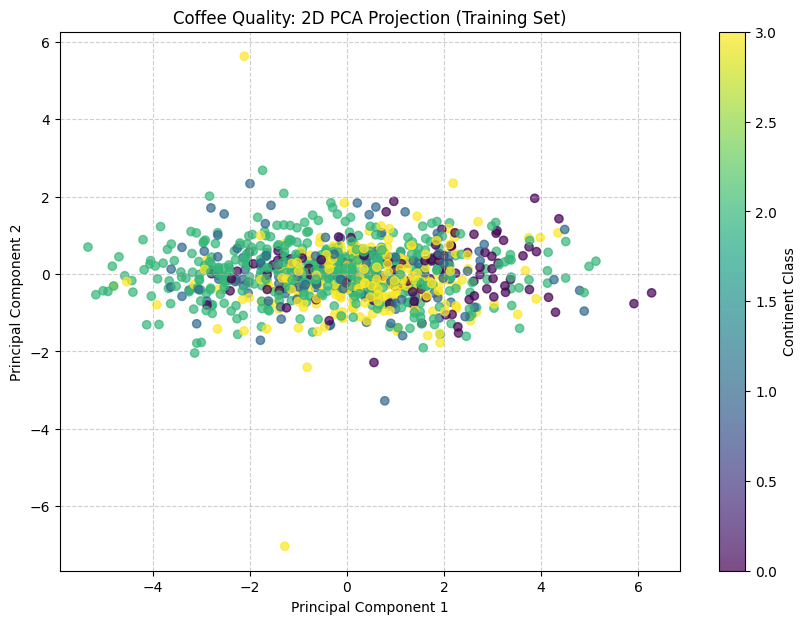

In [ ]:
from sklearn.decomposition import PCA

# Convert One-Hot labels back to single integers for coloring
y_labels = np.argmax(y_train_oh, axis=1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_labels, cmap='viridis', alpha=0.7)
plt.title('Coffee Quality: 2D PCA Projection (Training Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Continent Class')
plt.grid(True, linestyle='--', alpha=0.6)

We see that the colors are all mixed up, so we might need a deeper network (more hidden layers) to find the non-linear boundaries.

Let us do the same on our validation and test sets.

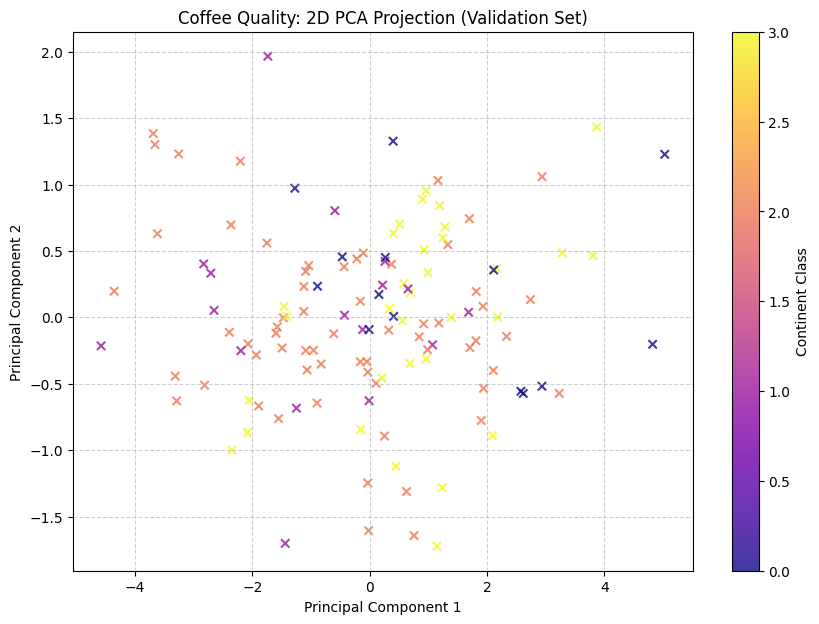

In [ ]:
from sklearn.decomposition import PCA

y_val_labels = np.argmax(y_val_oh, axis=1)
pca = PCA(n_components=2)
X_val_pca = pca.fit_transform(X_val)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_val_pca[:, 0], X_val_pca[:, 1], c=y_val_labels, cmap='plasma', marker='x', alpha=0.8)
plt.title('Coffee Quality: 2D PCA Projection (Validation Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Continent Class')
plt.grid(True, linestyle='--', alpha=0.6)

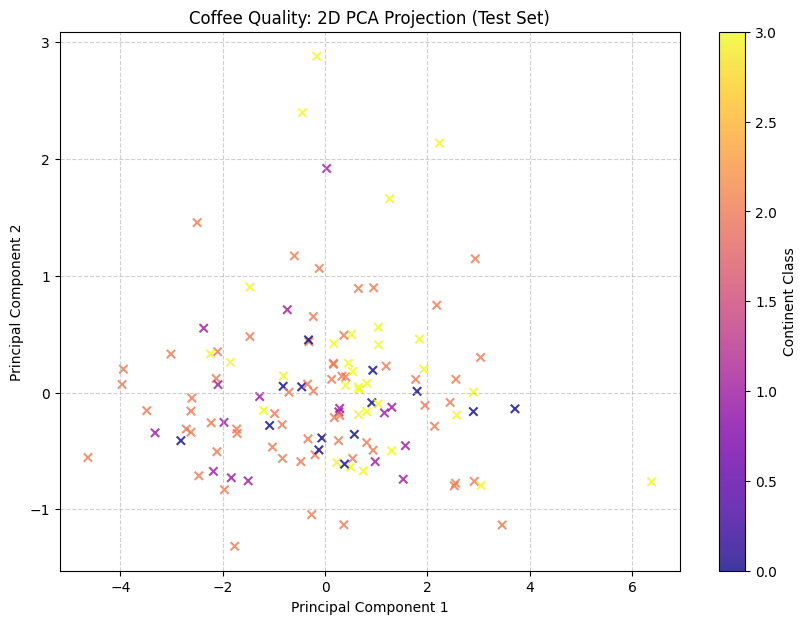

In [ ]:
from sklearn.decomposition import PCA

y_test_labels = np.argmax(y_test_oh, axis=1)
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_labels, cmap='plasma', marker='x', alpha=0.8)
plt.title('Coffee Quality: 2D PCA Projection (Test Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Continent Class')
plt.grid(True, linestyle='--', alpha=0.6)

We see that our validation set and test set data is plotted visually similar to the training set.

There is a class imbalance where North America, with the highest percentage, is 50% of our data, while Africa, with the lowest percentage, is around 11% of our data. Random oversampling simply duplicates existing minority samples, which can lead to overfitting. **SMOTE (Synthetic Minority Over-sampling Technique)** creates new, synthetic examples by interpolating between existing minority points. This provides the model with more diverse 'examples' of the African and Asian coffee profiles, leading to better generalization and higher test accuracy.

After this, we convert the variable X_train to the datatype torch.Tensor and assign the return value to variable X_train. We do the same for y_train_oh, X_val and y_val_oh, X_test, and y_test_oh.

In [ ]:
import torch
from imblearn.over_sampling import SMOTE

# SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train_oh)

X_train = torch.tensor(X_train_res.values, dtype=torch.float32)
X_val   = torch.tensor(X_val.values, dtype=torch.float32)
X_test  = torch.tensor(X_test.values, dtype=torch.float32)

y_train_oh = torch.tensor(y_train_res, dtype=torch.float32)
y_val_oh   = torch.tensor(y_val_oh, dtype=torch.float32)
y_test_oh  = torch.tensor(y_test_oh, dtype=torch.float32)

To confirm, let us see the updated length of both our X_train and y_train_oh.

In [ ]:
print(f"After SMOTE - X: {X_train.shape[0]}, y: {y_train_oh.shape[0]}")

After SMOTE - X: 2020, y: 2020


### **Setting up our Neural Network**

Now, we must set up our Neural Network. As we saw on our plot, we must add more hidden layers and expand our input layer to find more patterns. We will be using relu as our activation function because our network will be deeper and this would prevent vanishing gradients.

The number of hidden layers is based on the "Funnel" Architecture. This design is where each subsequent layer has fewer neurons than the one before it.

- Layer 1 (64 neurons): The first layer is the widest because it needs to capture all the raw interactions between your input features (like Acidity, Aroma, and Body). It creates a high-dimensional map of the data.
- Layer 2 (32 neurons): This layer begins to condense those raw features into "complex" patterns.
- Layer 3 (16 neurons): The final hidden layer distills the information down to the most essential "signatures" that distinguish a coffee's continent of origin.

This is low enough that the model is forced to learn general rules about coffee instead of memorizing specific samples.

In [ ]:
from neural_networks import NeuralNetwork

input_size = X_train.shape[1]
num_classes = y_train_oh.shape[1]

list_hidden = [64, 32, 16]
network = NeuralNetwork(input_size=input_size, num_classes=num_classes, list_hidden=list_hidden, activation= 'relu')

ModuleNotFoundError: No module named 'neural_networks'

Now, let us create our neural network and print it.

In [ ]:
network.create_network()
print(network)

Now, we must initialize the weights of our model. We will be using the init_weights() function in the NeuralNetwork class used in our lab notebook.

In [ ]:
network.init_weights()

Now, we must visualize the weights and bias for all our layers.



In [ ]:
print(network.layers[0].weight)
print(network.layers[0].bias)

In [ ]:
print(network.layers[2].weight)
print(network.layers[2].bias)

In [ ]:
print(network.layers[4].weight)
print(network.layers[4].bias)

In [ ]:
print(network.layers[6].weight)
print(network.layers[6].bias)

### **Forward propagation**

First we want to perform the forward propagation manually by using the forward_manual() function in the NeuralNetwork class from our lab notebook.

In [ ]:
scores, probabilities = network.forward_manual(torch.tensor(X_train[0:1]), verbose=True)

Now we will use the pre-implemented forward() function of the model in Pytorch. We do this to confirm that the results are similar to the previous output.

In [ ]:
scores_pt, probabilities_pt = network.forward(X_train[0:1].clone().detach().float(), verbose=True)

### **Getting the predictions**

Now, we must get the prediction from randomly selected 20 instances in our dataset. We will be using the predict() function in the NeuralNetwork class from our lab notebook.

In [ ]:
np.random.seed(20)
random_indices = np.random.randint(X_train.shape[0], size=20)
print('Random indices: ', random_indices)

Now, we also compute for the scores and probabilities of the random training instances by calling the function forward().

In [ ]:
scores, probabilities = network.forward(X_train[random_indices].clone().detach().float())








We then print the raw scores and the probabilities of our randomized set.

In [ ]:
print('Raw scores (logits):\n', scores)

In [ ]:
print('Probabilities:\n', probabilities)

Now, we call the function predict().

In [ ]:
predictions = network.predict(probabilities)
print(predictions)

### **Calculating the loss**

Cross-Entropy is specifically designed for Multi-class Classification (like our model with the classes Africa, Asia, North America, and South America). It is best used for our neural network since the model needs to output a probability for each class.

In [ ]:
import torch.nn as nn
criterion = nn.CrossEntropyLoss()

Now, we get the target classes of the random training examples from the previous step.

In [ ]:
target_classes = torch.argmax(y_train_oh[random_indices], dim=1).long()

print('Target classes: ', target_classes)
print('Data type:      ', target_classes.dtype)

Now, we compute for the loss. The loss function accepts the raw scores, not the probabilities.

In [ ]:
loss = criterion(scores, target_classes)

print('Loss: ', loss.item())

We get a loss of 1.38, which is pretty high. We must lower our loss by performing back propagation on our model.

### **Backward Propagation**

The process of backpropagation is used to update the weights by looking at the loss we got.


A learning rate (lr) of 0.001 is used as it provides a balance between rapid training and the risk of overshooting the global minimum. Meanwhile, the weight decay (1e−4) acts as L2 regularization, adding a small penalty to the loss based on the magnitude of the weights. This prevents any single neuron from becoming too dominant, which helps the model generalize better to new coffee samples rather than memorizing the training noise. Additionally, a ReduceLROnPlateau scheduler is implemented to automatically halve the learning rate if the validation loss stalls for 10 epochs, allowing the network to "fine-tune" its way toward a more stable global minimum.

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(network.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
 )
optimizer.zero_grad()
loss.backward()
optimizer.step()
print(network.layers[0].weight)

### **Training Pipeline**

Now, we will train the model using mini-batch gradient descent with PyTorch's DataLoader pipeline.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

y_train_indices = torch.argmax(y_train_oh, dim=1).long()
train_dataset = TensorDataset(X_train.float(), y_train_indices)
data_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Before we train our model, we must set our max epoch to 500. Neural networks can technically train forever, so we set a hard limit at 500. For a dataset of our size (around 1,000 coffee samples), 500 epochs is usually more than enough time for the weights to find their optimal values, without overfitting.

In [ ]:
e = 0
max_epochs = 500
previous_loss = float('inf')
is_converged = False
losses = []

Now, we train our model.

In [ ]:
network.train()

while e < max_epochs and is_converged is not True:

    current_epoch_loss = 0.0

    for X, y in data_loader:
        optimizer.zero_grad()
        scores, probabilities = network.forward(X.float())
        loss = criterion(scores, y)
        loss.backward()
        optimizer.step()
        current_epoch_loss += loss.item()

    average_loss = current_epoch_loss / len(data_loader)
    losses.append(average_loss)
    scheduler.step(average_loss)

    print('Epoch:', e + 1, '\tLoss: {:.6f}'.format(average_loss))

    if abs(previous_loss - average_loss) < 1e-7:
        is_converged = True
    else:
        previous_loss = average_loss
        e += 1

We see that our model never converged and has reached epoch 500 with a loss of ~0.90. However, it is still better than our previous loss of 1.38.

Now we must see how well our model performed in predicting the classes.

In [ ]:
network.eval()

with torch.no_grad():
    train_scores, train_probabilities = network.forward(X_train.float())
    predicted_indices = torch.argmax(train_scores, dim=1)

y_train_indices = torch.argmax(y_train_oh, dim=1)
num_correct = (predicted_indices == y_train_indices).sum().item()

print(f"Correct: {num_correct} / {len(y_train_indices)}")
print(f"Accuracy: {(num_correct / len(y_train_indices)) * 100:.2f}%")

network.train()

We see that our model performed with around ~72% accuracy.

### **Trained Network on Validation Set data**



To see if our model did not overfit, we must use our model on the validation set. Validation Phase is a critical step where the model's generalization ability is tested on "unseen" coffee samples without updating any weights.

In [ ]:
network.eval()
val_epoch_loss = 0

with torch.no_grad():
    X_val = torch.from_numpy(X_val).float() if isinstance(X_val, np.ndarray) else X_val.float()
    scores, probabilities = network.forward(X_val)
    y_val_indices = torch.argmax(y_val_oh, dim=1).long()

    val_loss = criterion(scores, y_val_indices)
    val_epoch_loss = val_loss.item()
    _, predicted = torch.max(scores, 1)

network.train()

In [ ]:
correct = (predicted == y_val_indices).sum().item()
val_accuracy = correct / len(y_val_indices)

print(f"Correct: {correct}/{len(y_val_indices)}")
print(f"Accuracy: {val_accuracy:.2%}")

We see that our model performed at around ~39% accuracy. Our model has performed worse on the validation set.

### **Trained and Validated Network on Test Set data**

In [ ]:
network.eval()
test_loss = 0

with torch.no_grad():
    X_test = torch.from_numpy(X_test).float() if isinstance(X_test, np.ndarray) else X_test.float()
    scores, probabilities = network.forward(X_test)
    y_test_indices = torch.argmax(y_test_oh, dim=1).long()

    test_loss = criterion(scores, y_test_indices)
    test_epoch_loss = test_loss.item()

    _, predicted_test = torch.max(scores, 1)

In [ ]:
correct = (predicted_test == y_test_indices).sum().item()
test_accuracy = correct / len(y_test_indices)

print(f"Correct: {correct}/{len(y_test_indices)}")
print(f"Accuracy: {test_accuracy:.2%}")

After using our model on the test set, it was able to achieve around ~40% accuracy. While the overall accuracy remains modest, it exceeds the 25% baseline for random classification in a four-class problem, indicating that the network has successfully extracted non-random patterns from the coffee chemical profiles.

We observed consistency across the validation and test sets, suggesting that the model has achieved a stable generalization and is not suffering from issues like overfitting.

In [ ]:
x_values = [i for i in range(len(losses))]
y_values = losses

plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, label='Training Loss')
plt.title('Coffee Classification: Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('CrossEntropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The model starts with a high Cross-Entropy Loss (around 1.385). In the first 200 epochs, there is a steep, consistent decline. This represents the "rapid learning" phase where the model is quickly adjusting its weights to find the most obvious patterns in the coffee data.

After epoch 200, the curve flattens out, hovering around a loss of 0.90. This indicates that the model has converged. It has learned as much as it can from the current features and architecture.

The constant up-and-down "zigzag" motion in the tail is because the model updates its weights based on a small batch of coffee samples rather than the whole 2,020 at once, the loss fluctuates slightly depending on how "difficult" or "easy" a specific batch is.


A loss of ~0.90 suggests the model is making progress but is still "uncertain" about many samples, likely due to the class imbalance on our data.

## **Evaluation & Results**

### **Feature Importance Analysis**

We get each feature's importance on each model to see which ones are the most indicative of the coffee's origin continent.

For the Logistic Regression Model, we use mean absolute coefficients across the classes.

For the Random Forest, we use impurity-based feature importance.

For the Neural Network, we use permutation importance and get the drop in accuracy when each feature is shuffled.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

feature_names = final_features if 'final_features' in globals() else ["Aroma", "Aftertaste", "Acidity", "Body", "Balance", "Color"]

X_test_np = X_test.detach().cpu().numpy() if isinstance(X_test, torch.Tensor) else np.asarray(X_test)
y_test_idx = torch.argmax(y_test_oh, dim=1).detach().cpu().numpy() if isinstance(y_test_oh, torch.Tensor) else np.argmax(y_test_oh, axis=1)

logit_imp_df = None
if 'multinomial_model' in globals() and hasattr(multinomial_model, 'coef_'):
    logit_importance = np.mean(np.abs(multinomial_model.coef_), axis=0)
    logit_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': logit_importance
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

rf_imp_df = None
rf_model = grid.best_estimator_ if 'grid' in globals() and hasattr(grid, 'best_estimator_') else None
if rf_model is not None and hasattr(rf_model, 'feature_importances_'):
    rf_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

nn_perm_df = None
if 'network' in globals():
    network.eval()
    with torch.no_grad():
        X_test_nn = X_test.float() if isinstance(X_test, torch.Tensor) else torch.tensor(X_test_np, dtype=torch.float32)
        y_test_nn = torch.tensor(y_test_idx, dtype=torch.long)

        base_scores, _ = network.forward(X_test_nn)
        base_pred = torch.argmax(base_scores, dim=1)
        base_acc = (base_pred == y_test_nn).float().mean().item()

        drops = []
        for j, fname in enumerate(feature_names):
            X_perm = X_test_nn.clone()
            perm_idx = torch.randperm(X_perm.shape[0])
            X_perm[:, j] = X_perm[perm_idx, j]

            scores_perm, _ = network.forward(X_perm)
            pred_perm = torch.argmax(scores_perm, dim=1)
            perm_acc = (pred_perm == y_test_nn).float().mean().item()
            drops.append(base_acc - perm_acc)

    nn_perm_df = pd.DataFrame({
        'Feature': feature_names,
        'AccuracyDrop': drops
    }).sort_values('AccuracyDrop', ascending=False).reset_index(drop=True)

print('Logistic Regression feature importance (abs coef):')
display(logit_imp_df if logit_imp_df is not None else pd.DataFrame({'Info': ['Logistic model not available']}))

print('Random Forest feature importance:')
display(rf_imp_df if rf_imp_df is not None else pd.DataFrame({'Info': ['Random Forest model not available']}))

print('Neural Network permutation importance (test accuracy drop):')
display(nn_perm_df if nn_perm_df is not None else pd.DataFrame({'Info': ['Neural network not available']}))

Looking at the rankings per model, we see inconsistencies in how each feature affect the prediction of the models.

To get a generalized insight on to which features are most indicative across the classes, we rank them according to their average ranks in all classes.

In [ ]:
summary_df = pd.DataFrame({'Feature': feature_names})

if logit_imp_df is not None and not logit_imp_df.empty:
    summary_df = summary_df.merge(
        logit_imp_df[['Feature', 'Importance']].rename(columns={'Importance': 'Logistic_AbsCoef'}),
        on='Feature',
        how='left'
    )

if rf_imp_df is not None and not rf_imp_df.empty:
    summary_df = summary_df.merge(
        rf_imp_df[['Feature', 'Importance']].rename(columns={'Importance': 'RandomForest_Importance'}),
        on='Feature',
        how='left'
    )

if nn_perm_df is not None and not nn_perm_df.empty:
    summary_df = summary_df.merge(
        nn_perm_df[['Feature', 'AccuracyDrop']].rename(columns={'AccuracyDrop': 'NeuralNet_PermDrop'}),
        on='Feature',
        how='left'
    )

metric_cols = [c for c in ['Logistic_AbsCoef', 'RandomForest_Importance', 'NeuralNet_PermDrop'] if c in summary_df.columns]

for col in metric_cols:
    summary_df[f'Rank_{col}'] = summary_df[col].rank(ascending=False, method='average')

if metric_cols:
    rank_cols = [f'Rank_{c}' for c in metric_cols]
    summary_df['Average_Rank'] = summary_df[rank_cols].mean(axis=1)
    summary_df = summary_df.sort_values('Average_Rank').reset_index(drop=True)

print('Feature importance summary across models:')
display(summary_df.round(4))

Balance is shown to be the most flexible telling feature with an average rank of 2 across the models. Having been ranked as not dropping below third place, as well as scoring first place in Neural Networks, Balance remains as the strongest predictor of continent origin.

Interestingly, Body, despite being the strongest feature in Logistic Regression, scored fifth on Random Forest and Neural Networks. As our non-linear models realize that Body isn't useful, it indicates that while the feature affects prediction in a straight-line manner, it might not be that strong once feature interactions are taken into account.

### **Cross-Model Performance Discussion**


In [ ]:
rows = []

if 'multinomial_model' in globals():
    pred_log = multinomial_model.predict(X_test_np)
    rows.append({
        'Model': 'Logistic Regression (SGD)',
        'Accuracy': accuracy_score(y_test_idx, pred_log),
        'Precision_weighted': precision_score(y_test_idx, pred_log, average='weighted', zero_division=0),
        'Recall_macro': recall_score(y_test_idx, pred_log, average='macro', zero_division=0),
        'F1_macro': f1_score(y_test_idx, pred_log, average='macro', zero_division=0)
    })

if rf_model is not None:
    pred_rf = rf_model.predict(X_test_np)
    rows.append({
        'Model': 'Random Forest (Tuned)',
        'Accuracy': accuracy_score(y_test_idx, pred_rf),
        'Precision_weighted': precision_score(y_test_idx, pred_rf, average='weighted', zero_division=0),
        'Recall_macro': recall_score(y_test_idx, pred_rf, average='macro', zero_division=0),
        'F1_macro': f1_score(y_test_idx, pred_rf, average='macro', zero_division=0)
    })

if 'network' in globals():
    network.eval()
    with torch.no_grad():
        scores_nn, _ = network.forward(X_test.float() if isinstance(X_test, torch.Tensor) else torch.tensor(X_test_np, dtype=torch.float32))
        pred_nn = torch.argmax(scores_nn, dim=1).detach().cpu().numpy()
    rows.append({
        'Model': 'Neural Network',
        'Accuracy': accuracy_score(y_test_idx, pred_nn),
        'Precision_weighted': precision_score(y_test_idx, pred_nn, average='weighted', zero_division=0),
        'Recall_macro': recall_score(y_test_idx, pred_nn, average='macro', zero_division=0),
        'F1_macro': f1_score(y_test_idx, pred_nn, average='macro', zero_division=0)
    })

comparison_df = pd.DataFrame(rows)
print('Model comparison on test set:')
display(comparison_df)

While Logistic Regression performs the best in terms of accuracy, we take into account the nature of our dataset. It is small, multiclass, and imbalanced, which gives importance to a metric like Macro-F1, as it takes into account feature imbalance and measures the model with how it predicts even the minority class. Consequently, Random Forest and Neural Network is marginally better at predicting minority classes than Logistic Regression.

Interestingly, Neural Network's high precision but low accuracy indicate that although it might be confident in dominant classes, it still makes enough wrong predictions nonetheless such that it reduced its accuracy.

In general all the models have likely been affected by a couple factors.

1. Looking at the preliminary EDA, we see that the six sensory scores cluster at roughly the same ranges. This shows the real-world reality that most coffees taste similar.
2. Class imbalance and small dataset mean we might not get the full picture, or the most accurate distribution of how coffees differ. Nonetheless, this trickles down to how a single missclassification will greatly affect the metrics.

Logistic Regression having a linear decision boundary means that it is more likely to correctly classify a dominant class in the dataset, thus inflating its accuracy. Meanwhile, minority classes are harder to predict, as shown in LR's lowest Macro-F1. Although a Grid Search was used to tune the model, LR's fundamental straight-line decision making is still hindered when it comes to less-represented data.

Random Forest's tree-based ensembles capture feature interaction, moreover, its non-linear decision boundary and a large number of decision trees result to minority class regions being more represented. Although its accuracy dropped against LR due to less accurate predictions on the dominant class, this is a trade-off that is often desirable for imbalanced datasets such as ours.

In Neural Network, the usage of SMOTE's synthetically rebalanced classes result to the model not matching the reality of the dataset's class imbalance, resulting to predictions in the dominant class being less accurate, albeit improving the model's ability to detect minority classes. Having a bigger precision also means that the model learned to be more selective in predicting classes, which may have been caused by the 64-32-16 architecture which compresses inputs  into small representations, forcing the network to learn more indicative features, but at the cost of coverage.  

Overall, handling data imbalances and scarcity along with overlapping feature distributions through preprocessing and hyperparameter tuning is a challenge to deal with datasets such as ours. Having models perform at an improved performance than random guessing still signify that further work into domains such as this is needed, as data collection in reality is often hindered by logistical limitations.

## **AI Declaration**

The group utilized AI tools, including Google Gemini, ChatGPT, throughout the development and documentation of this project. The AI was used to assist in the following areas:

* Code debugging (Syntax error resolution and traceback analysis)
* Implementation of weight decay, and learning rate scheduling
* Effects of SMOTE
* Result Interpretation (analysis of loss convergence)
* Grammar checking

All AI-generated outputs were reviewed, and verified to ensure accuracy and alignment with machine learning best practices.